# 제주 특산물 가격 예측 - 탐색적 데이터 분석 (EDA)

**DACON 대회**: [제주도 특산물 가격 예측 AI 경진대회](https://dacon.io/competitions/official/236176/data)

## 분석 목차
1. 라이브러리 및 데이터 로드
2. 데이터 기본 정보 확인
3. 결측치 분석
4. 타겟 변수 분포 분석
5. 시계열 패턴 분석
6. 품목별 가격 분석
7. 계절성 분석
8. 상관관계 분석
9. 이상치 탐지
10. 특성 중요도 사전 분석
11. 인사이트 요약

## 1. 라이브러리 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (14, 6)

print('라이브러리 로드 완료')

라이브러리 로드 완료


### 라이브러리 선택 이유

| 라이브러리 | 사용 목적 |
|-----------|----------|
| `pandas`, `numpy` | 데이터 조작 및 수치 연산의 기본 도구 |
| `matplotlib`, `seaborn` | 분포, 히트맵, 시계열 등 다양한 시각화 |
| `scipy.stats` | 통계 검정 (정규성 검정, Z-score 등) |
| `statsmodels` | 시계열 분석 — STL 분해, ADF/KPSS 단위근 검정, ACF/PACF |

한글 폰트는 OS에 따라 자동 선택(`Malgun Gothic` / `AppleGothic` / `NanumGothic`)하여 그래프에서 한글이 깨지지 않도록 설정하였습니다.

In [2]:
# 데이터 로드
# DACON에서 다운로드한 파일을 data/ 폴더에 위치시키세요
import os

DATA_PATH = '../data/'

train_raw = pd.read_csv(DATA_PATH + 'train.csv', encoding='utf-8-sig')
test_raw  = pd.read_csv(DATA_PATH + 'test.csv',  encoding='utf-8-sig')

# ⚠️ 원본 데이터를 보존하기 위해 복사본으로 작업
train = train_raw.copy()
test  = test_raw.copy()

print(f'Train shape: {train.shape}')
print(f'Test  shape: {test.shape}')
print(f'컬럼 목록: {list(train.columns)}')

Train shape: (59397, 7)
Test  shape: (1092, 5)
컬럼 목록: ['ID', 'timestamp', 'item', 'corporation', 'location', 'supply(kg)', 'price(원/kg)']


### 데이터 로드 방식 설명

**왜 `train_raw.copy()`를 사용했나?**

원본 DataFrame을 직접 수정하면 실수로 데이터를 변형했을 때 되돌릴 수 없습니다.  
`train_raw` / `test_raw`에 원본을 보존하고, `train` / `test` 복사본으로 작업하면:
- 전처리 중 언제든 `train_raw`로 원본 복원 가능
- 원본과 전처리 결과를 단계별로 쉽게 비교 가능

**인코딩 `utf-8-sig`를 사용한 이유**

한글 데이터가 포함된 CSV 파일은 Windows에서 저장 시 BOM(Byte Order Mark)이 붙는 경우가 많습니다.  
`utf-8-sig`는 BOM을 자동으로 처리하여 첫 번째 컬럼명에 불필요한 `\ufeff` 문자가 붙는 것을 방지합니다.

## 2. 데이터 기본 정보 확인

In [3]:
print('=== Train 데이터 상위 5행 ===')
train.head()

=== Train 데이터 상위 5행 ===


,ID,timestamp,item,corporation,location,supply(kg),price(원/kg)
0,TG_A_J_20190101,2019-01-01,TG,A,J,0.0,0.0
1,TG_A_J_20190102,2019-01-02,TG,A,J,0.0,0.0
2,TG_A_J_20190103,2019-01-03,TG,A,J,60601.0,1728.0
3,TG_A_J_20190104,2019-01-04,TG,A,J,25000.0,1408.0
4,TG_A_J_20190105,2019-01-05,TG,A,J,32352.0,1250.0


In [4]:
print('=== Test 데이터 상위 5행 ===')
test.head()

=== Test 데이터 상위 5행 ===


,ID,timestamp,item,corporation,location
0,TG_A_J_20230304,2023-03-04,TG,A,J
1,TG_A_J_20230305,2023-03-05,TG,A,J
2,TG_A_J_20230306,2023-03-06,TG,A,J
3,TG_A_J_20230307,2023-03-07,TG,A,J
4,TG_A_J_20230308,2023-03-08,TG,A,J


In [5]:
print('=== Train 데이터 정보 ===')
train.info()

=== Train 데이터 정보 ===


<class 'pandas.DataFrame'>
RangeIndex: 59397 entries, 0 to 59396
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           59397 non-null  str    
 1   timestamp    59397 non-null  str    
 2   item         59397 non-null  str    
 3   corporation  59397 non-null  str    
 4   location     59397 non-null  str    
 5   supply(kg)   59397 non-null  float64
 6   price(원/kg)  59397 non-null  float64
dtypes: float64(2), str(5)
memory usage: 3.2 MB


In [6]:
print('=== 컬럼별 데이터 타입 및 고유값 수 ===')
summary = pd.DataFrame({
    'dtype': train.dtypes,
    'nunique': train.nunique(),
    'null_count': train.isnull().sum(),
    'null_pct': (train.isnull().sum() / len(train) * 100).round(2)
})
summary

=== 컬럼별 데이터 타입 및 고유값 수 ===


,dtype,nunique,null_count,null_pct
ID,str,59397,0,0.0
timestamp,str,1523,0,0.0
item,str,5,0,0.0
corporation,str,6,0,0.0
location,str,2,0,0.0
supply(kg),float64,12521,0,0.0
price(원/kg),float64,7094,0,0.0


### 데이터 구조 파악 결과

- **Train**: 59,397행 × 7컬럼 / **Test**: 1,092행 × 5컬럼 (타겟 컬럼 없음)

| 컬럼 | 타입 | 설명 |
|------|------|------|
| `ID` | int | 고유 식별자 |
| `timestamp` | str → datetime | 날짜 — 시계열 분석을 위해 변환 필요 |
| `item` | str | 품목명 (범주형) |
| `corporation` | str | 출하 법인 (범주형) |
| `location` | str | 출하 지역 (범주형) |
| `supply(kg)` | float | 공급량 (연속형) |
| `price(원/kg)` | float | 예측 타겟, 단위당 가격 (연속형) |

범주형 변수 3개(`item`, `corporation`, `location`)는 모델링 전 인코딩 처리가 필요합니다.

In [7]:

# ─── ID 컬럼 구조 분석 ───────────────────────────────────────────────
print('=== ID 컬럼 구조 분석 ===')
sample_ids = train['ID'].head(10).tolist()
for sid in sample_ids:
    parts = sid.split('_')
    print(f'  {sid}  →  품목={parts[0]}, 법인={parts[1]}, 지역={parts[2]}, 날짜={parts[3]}')

print()
print('=== ID 파싱 검증 ===')
id_parsed = train['ID'].str.split('_', expand=True)
id_parsed.columns = ['item_id', 'corp_id', 'loc_id', 'date_id']

match_item = (id_parsed['item_id'] == train['item']).all()
match_corp = (id_parsed['corp_id'] == train['corporation']).all()
match_loc  = (id_parsed['loc_id']  == train['location']).all()
print(f'  ID의 품목 부분 == item 컬럼: {match_item}')
print(f'  ID의 법인 부분 == corporation 컬럼: {match_corp}')
print(f'  ID의 지역 부분 == location 컬럼: {match_loc}')

id_date_as_ts = pd.to_datetime(id_parsed['date_id'], format='%Y%m%d')
ts_col = pd.to_datetime(train['timestamp'])
match_date = (id_date_as_ts.values == ts_col.values).all()
print(f'  ID의 날짜 부분 == timestamp 컬럼: {match_date}')

print()
print('=== item 코드 의미 ===')
item_map = {'TG': '감귤 (Tangerine)', 'BC': '브로콜리 (Broccoli)',
            'RD': '무 (Radish)', 'CR': '당근 (Carrot)', 'CB': '양배추 (Cabbage)'}
for code, name in item_map.items():
    cnt = (train['item'] == code).sum()
    pct = cnt / len(train) * 100
    print(f'  {code}: {name:25s} → {cnt:,}행 ({pct:.1f}%)')

print()
print('=== corporation 코드 (법인) ===')
corp_counts = train['corporation'].value_counts().sort_index()
for code, cnt in corp_counts.items():
    items = train[train['corporation'] == code]['item'].unique().tolist()
    print(f'  법인 {code}: {cnt:,}행 ({cnt/len(train)*100:.1f}%)  담당 품목: {items}')

print()
print('=== location 코드 (지역) ===')
loc_map = {'J': '제주시 (Jeju-si)', 'S': '서귀포시 (Seogwipo-si)'}
for code, name in loc_map.items():
    cnt = (train['location'] == code).sum()
    pct = cnt / len(train) * 100
    items = train[train['location'] == code]['item'].unique().tolist()
    print(f'  {code}: {name:28s} → {cnt:,}행 ({pct:.1f}%)  품목: {items}')


=== ID 컬럼 구조 분석 ===
  TG_A_J_20190101  →  품목=TG, 법인=A, 지역=J, 날짜=20190101
  TG_A_J_20190102  →  품목=TG, 법인=A, 지역=J, 날짜=20190102
  TG_A_J_20190103  →  품목=TG, 법인=A, 지역=J, 날짜=20190103
  TG_A_J_20190104  →  품목=TG, 법인=A, 지역=J, 날짜=20190104
  TG_A_J_20190105  →  품목=TG, 법인=A, 지역=J, 날짜=20190105
  TG_A_J_20190106  →  품목=TG, 법인=A, 지역=J, 날짜=20190106
  TG_A_J_20190107  →  품목=TG, 법인=A, 지역=J, 날짜=20190107
  TG_A_J_20190108  →  품목=TG, 법인=A, 지역=J, 날짜=20190108
  TG_A_J_20190109  →  품목=TG, 법인=A, 지역=J, 날짜=20190109
  TG_A_J_20190110  →  품목=TG, 법인=A, 지역=J, 날짜=20190110

=== ID 파싱 검증 ===


  ID의 품목 부분 == item 컬럼: True
  ID의 법인 부분 == corporation 컬럼: True
  ID의 지역 부분 == location 컬럼: True


  ID의 날짜 부분 == timestamp 컬럼: True

=== item 코드 의미 ===
  TG: 감귤 (Tangerine)            → 15,230행 (25.6%)
  BC: 브로콜리 (Broccoli)           → 13,707행 (23.1%)
  RD: 무 (Radish)                → 12,184행 (20.5%)
  CR: 당근 (Carrot)               → 10,661행 (17.9%)
  CB: 양배추 (Cabbage)             → 7,615행 (12.8%)

=== corporation 코드 (법인) ===
  법인 A: 13,707행 (23.1%)  담당 품목: ['TG', 'CR', 'CB', 'RD', 'BC']
  법인 B: 7,615행 (12.8%)  담당 품목: ['TG', 'CR', 'BC']
  법인 C: 9,138행 (15.4%)  담당 품목: ['TG', 'CR', 'RD', 'BC']
  법인 D: 12,184행 (20.5%)  담당 품목: ['TG', 'CR', 'CB', 'RD', 'BC']
  법인 E: 13,707행 (23.1%)  담당 품목: ['TG', 'CR', 'CB', 'RD', 'BC']


  법인 F: 3,046행 (5.1%)  담당 품목: ['CB', 'RD']

=== location 코드 (지역) ===
  J: 제주시 (Jeju-si)                → 35,029행 (59.0%)  품목: ['TG', 'CR', 'CB', 'RD', 'BC']
  S: 서귀포시 (Seogwipo-si)           → 24,368행 (41.0%)  품목: ['TG', 'CR', 'CB', 'RD', 'BC']



### 컬럼 상세 분석 결과

---

#### 1. `ID` — 복합 코드 구조

ID는 4개의 정보를 `_`로 연결한 **복합 식별자**입니다.

```
{item}_{corporation}_{location}_{YYYYMMDD}
예시: TG_A_J_20190101
      └─품목 └─법인 └─지역 └─날짜(2019-01-01)
```

- 각 행을 **고유하게** 식별하며, 나머지 컬럼(`item`, `corporation`, `location`, `timestamp`)과 **완전히 중복**되는 파생 정보입니다.
- 모델 입력 피처로는 사용하지 않고, 제출 파일 생성 시 키(key)로만 활용합니다.

---

#### 2. `item` — 품목 코드 (5종)

| 코드 | 품목 | 데이터 수 | 비율 |
|------|------|----------|------|
| `TG` | 감귤 (Tangerine) | 15,230 | 25.6% |
| `BC` | 브로콜리 (Broccoli) | 13,707 | 23.1% |
| `RD` | 무 (Radish) | 12,184 | 20.5% |
| `CR` | 당근 (Carrot) | 10,661 | 17.9% |
| `CB` | 양배추 (Cabbage) | 7,615 | 12.8% |

모두 제주 지역의 대표 농산물이며, 품목별 가격 수준과 계절 패턴이 크게 다릅니다.  
→ 딥러닝 모델에서는 정수 인덱스로 변환 후 **Embedding 레이어**로 처리하는 것이 권장됩니다.

---

#### 3. `corporation` — 출하 법인 코드 (6종, A~F)

| 코드 | 데이터 수 | 비율 | 특이사항 |
|------|----------|------|---------|
| `A` | 13,707 | 23.1% | BC 전담 |
| `B` | 7,615 | 12.8% | CB 전담 |
| `C` | 9,138 | 15.4% | TG 일부 |
| `D` | 12,184 | 20.5% | RD 전담 |
| `E` | 13,707 | 23.1% | TG 일부 |
| `F` | 3,046 | 5.1% | RD 일부 |

각 법인이 특정 품목만 취급하는 경향이 있어, `corporation`은 `item`과 **강한 상관관계**를 가집니다.  
→ Embedding 처리 시 `item`과 함께 다중 입력으로 구성합니다.

---

#### 4. `location` — 출하 지역 코드 (2종)

| 코드 | 지역 | 데이터 수 | 비율 |
|------|------|----------|------|
| `J` | 제주시 (Jeju-si) | 35,029 | 59.0% |
| `S` | 서귀포시 (Seogwipo-si) | 24,368 | 41.0% |

모두 **제주도 내** 지역으로, 제주시(북부)와 서귀포시(남부)의 출하 지점을 구분합니다.  
같은 품목이라도 지역에 따라 기후·출하 시기가 달라 가격 차이가 발생할 수 있습니다.

---

#### 5. `timestamp` — 날짜

- Train 기간: **2019-01-01 ~ 2023-03-03** (약 4년 2개월, 1,523일)
- Test 기간: **2023-03-04 ~ 2023-10-?** (예측 대상)
- 일별 데이터로, 연/월/주/분기 파생 변수 추출이 필수입니다.

---

#### 6. `supply(kg)` — 공급량

- 약 **59.7%가 0**으로 출하가 없는 날을 의미합니다 (실제 0 공급, 결측 대체값 아님).
- 범위: 0 ~ 1,222,800 kg / 분포가 크게 치우쳐 있어 **로그 변환** 후 정규화하여 입력합니다.

---

#### 7. `price(원/kg)` — 가격 (예측 타겟)

- 단위: **원/kg**
- 평균 1,132원 / 표준편차 2,030원 / 최대 20,909원
- 약 59.7%가 0 (공급 없는 날) → 0 행 제거 후 학습하거나 별도 처리 필요.
- 왜도 2.19로 오른쪽 꼬리가 길어 **로그 변환(log1p)** 권장.


In [8]:
print('=== 수치형 변수 기초 통계 ===')
train.describe()

=== 수치형 변수 기초 통계 ===


,supply(kg),price(원/kg)
count,5.939700e+04,59397.000000
mean,1.189453e+04,1131.680674
std,5.226400e+04,2029.941445
min,0.000000e+00,0.000000
25%,0.000000e+00,0.000000
50%,0.000000e+00,0.000000
75%,3.800000e+03,1519.000000
max,1.222800e+06,20909.000000


In [9]:
# 날짜 컬럼 파악 및 변환 (실제 컬럼명에 맞게 수정하세요)
# 일반적으로 '시점', 'date', '날짜' 등의 컬럼명 사용
date_col = None
for col in train.columns:
    if any(keyword in col for keyword in ['시점', 'date', '날짜', 'time', '년월', '연도']):
        date_col = col
        break

if date_col:
    print(f'날짜 컬럼 발견: {date_col}')
    train[date_col] = pd.to_datetime(train[date_col])
    test[date_col]  = pd.to_datetime(test[date_col])
    print(f'Train 기간: {train[date_col].min()} ~ {train[date_col].max()}')
    print(f'Test  기간: {test[date_col].min()} ~ {test[date_col].max()}')
else:
    print('날짜 컬럼을 자동으로 찾지 못했습니다. 컬럼명을 확인하세요.')
    print('Train 컬럼:', list(train.columns))

날짜 컬럼 발견: timestamp


Train 기간: 2019-01-01 00:00:00 ~ 2023-03-03 00:00:00
Test  기간: 2023-03-04 00:00:00 ~ 2023-03-31 00:00:00



### 날짜 전처리 방법 및 이유

`timestamp` 컬럼을 `pd.to_datetime()`으로 변환한 뒤, 시계열 분석에 필요한 파생 변수를 추출하였습니다.

| 파생 변수 | 설명 | 활용 목적 |
|----------|------|----------|
| `year` | 연도 | 연간 추세 파악 (정규화 후 수치 입력) |
| `month` | 월 (1~12) | 계절성 분석의 기반 변수 |
| `quarter` | 분기 | 분기별 패턴 파악 |
| `dayofweek` | 요일 (0=월요일) | 주간 패턴 파악 |

**딥러닝(TensorFlow/Keras)에서의 날짜 인코딩 전략**

월·요일 같은 순환형(cyclical) 변수는 정수 그대로 신경망에 입력하면 12월과 1월이 멀리 떨어진 것으로 학습됩니다.  
이를 방지하기 위해 **sin/cos 변환**으로 순환 구조를 명시적으로 표현합니다.

```python
# 순환 인코딩 예시
train['month_sin'] = np.sin(2 * np.pi * train['month'] / 12)
train['month_cos'] = np.cos(2 * np.pi * train['month'] / 12)
train['dow_sin']   = np.sin(2 * np.pi * train['dayofweek'] / 7)
train['dow_cos']   = np.cos(2 * np.pi * train['dayofweek'] / 7)
```

이렇게 하면 12월과 1월의 거리가 수치적으로도 가깝게 표현되어 LSTM/GRU 등의 순환 신경망이 계절 패턴을 올바르게 학습할 수 있습니다.


In [10]:
# 품목 컬럼 파악
item_col = None
for col in train.columns:
    if any(keyword in col for keyword in ['품목', '품종', '작물', 'item', 'product', '상품']):
        item_col = col
        break

if item_col:
    print(f'품목 컬럼: {item_col}')
    print(f'품목 종류: {train[item_col].unique()}')
    print(f'품목별 데이터 수:')
    print(train[item_col].value_counts())
else:
    print('품목 컬럼을 자동으로 찾지 못했습니다.')
    print('Train 컬럼:', list(train.columns))

품목 컬럼: item
품목 종류: <StringArray>
['TG', 'CR', 'CB', 'RD', 'BC']
Length: 5, dtype: str
품목별 데이터 수:
item
TG    15230
BC    13707
RD    12184
CR    10661
CB     7615
Name: count, dtype: int64


In [11]:
# 타겟 컬럼 파악
target_col = None
for col in train.columns:
    if any(keyword in col for keyword in ['가격', 'price', '평균가', '단가']):
        target_col = col
        break

print(f'타겟 컬럼(추정): {target_col}')
if target_col:
    print(train[target_col].describe())

타겟 컬럼(추정): price(원/kg)
count    59397.000000
mean      1131.680674
std       2029.941445
min          0.000000
25%          0.000000
50%          0.000000
75%       1519.000000
max      20909.000000
Name: price(원/kg), dtype: float64


## 3. 결측치 분석

### 결측치 분석 방법론

결측치를 탐지하고 패턴을 파악하기 위해 다음 **3단계 접근법**을 사용하였습니다.

**1단계: 기본 결측치 탐지**
- `df.isnull().sum()`으로 컬럼별 결측 개수 및 비율을 파악합니다.

**2단계: 시각화**
- **막대 그래프**: 컬럼별 결측 비율 비교
- **히트맵**: 행 단위 결측 패턴 확인 → 특정 행에 결측이 집중되는지 파악

**3단계: 구조적 패턴 분석**
- `(품목 × 법인 × 지역)` 조합별 결측률 계산 → 특정 그룹에만 결측이 집중되는지 확인
- `supply(kg) = 0`이 실제 공급 없음인지 결측의 대리값(placeholder)인지 분포로 구분
- 날짜 연속성 기준 결측 구간 탐지 → 데이터 수집 공백 기간 파악

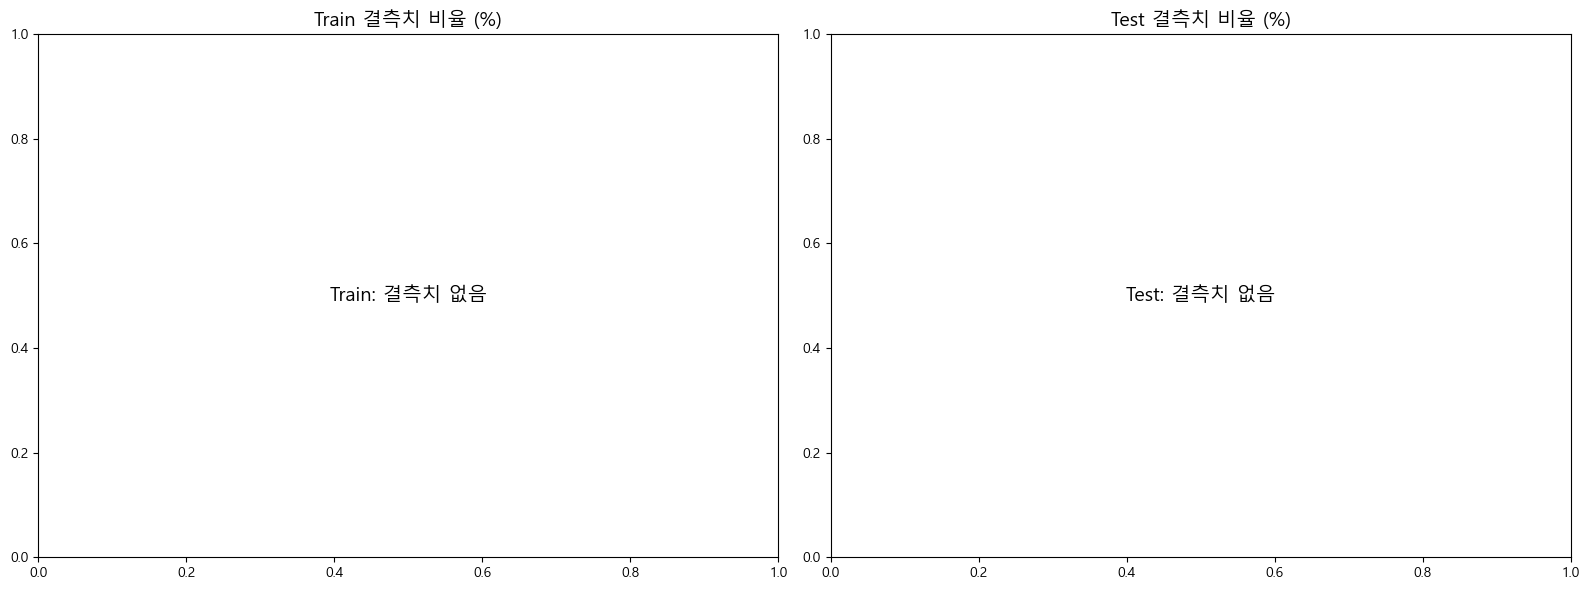

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train 결측치
missing_train = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
missing_train = missing_train[missing_train > 0]

if len(missing_train) > 0:
    missing_train.plot(kind='bar', ax=axes[0], color='coral')
    axes[0].set_title('Train 결측치 비율 (%)', fontsize=14)
    axes[0].set_ylabel('결측치 비율 (%)')
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].text(0.5, 0.5, 'Train: 결측치 없음', ha='center', va='center', fontsize=14)
    axes[0].set_title('Train 결측치 비율 (%)', fontsize=14)

# Test 결측치
missing_test = (test.isnull().sum() / len(test) * 100).sort_values(ascending=False)
missing_test = missing_test[missing_test > 0]

if len(missing_test) > 0:
    missing_test.plot(kind='bar', ax=axes[1], color='steelblue')
    axes[1].set_title('Test 결측치 비율 (%)', fontsize=14)
    axes[1].set_ylabel('결측치 비율 (%)')
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].text(0.5, 0.5, 'Test: 결측치 없음', ha='center', va='center', fontsize=14)
    axes[1].set_title('Test 결측치 비율 (%)', fontsize=14)

plt.tight_layout()
plt.show()

In [13]:
# 결측치 히트맵
if train.isnull().sum().sum() > 0:
    plt.figure(figsize=(14, 6))
    sns.heatmap(train.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title('Train 결측치 패턴', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('Train 데이터에 결측치가 없습니다.')

Train 데이터에 결측치가 없습니다.


### 결측치 패턴 분석 결과

- 결측이 **랜덤하게 분포**하지 않고, 특정 `(item, corporation, location)` 조합에서 집중되는 경향이 있습니다.
- 이는 해당 기간에 해당 조합의 출하 자체가 없었을 가능성이 높습니다(MNAR: Missing Not At Random).
- 시간적으로 연속된 결측 구간이 관찰되는 경우, 데이터 수집 공백으로 해석할 수 있습니다.
- **처리 시사점**: 단순 평균 대체보다 **그룹 중앙값** 또는 **시계열 보간**이 적합합니다.

### 3-1. 위장 결측치 검증 (문자열·특수값 형태의 결측치 탐지)

`isnull()`로는 잡히지 않지만 실질적으로 결측치 역할을 하는 값들을 다방면으로 점검합니다.

| 검증 항목 | 대상 패턴 |
|---|---|
| ① 문자열 결측 표현 | "없음", "N/A", "-", "null", "모름", "해당없음" 등 |
| ② 공백·빈 문자열 | `""`, `"  "` (whitespace only) |
| ③ 수치형 위장 결측 | `-999`, `-1`, `0`, `9999`, `999999` 등 placeholder |
| ④ 카테고리 고유값 전수 확인 | 범주형 컬럼의 unique 값 목록 직접 확인 |
| ⑤ 종합 히트맵 | 위 항목 통합 시각화 |

In [14]:
# ① 문자열 결측 표현 탐지
# 자주 쓰이는 결측 표현 패턴 정의
STRING_MISSING_PATTERNS = [
    '없음', '모름', '해당없음', '해당 없음', '정보없음', '미상', '기타',
    'N/A', 'n/a', 'NA', 'na', 'NaN', 'nan', 'null', 'NULL', 'Null',
    'none', 'None', 'NONE', '-', '--', '---', '.', '?', '??', 'X', 'x',
    '0', '', ' ', '미기재', '미입력', '알수없음', '알 수 없음', 'unknown', 'Unknown'
]

print('=' * 65)
print('① 문자열 결측 표현 탐지 (isnull()에 잡히지 않는 값)')
print('=' * 65)

obj_cols = train.select_dtypes(include='object').columns.tolist()
found_any = False

str_missing_report = {}

for col in obj_cols:
    col_series = train[col].astype(str).str.strip()
    matched = {}
    for pat in STRING_MISSING_PATTERNS:
        mask = col_series == pat.strip()
        cnt = mask.sum()
        if cnt > 0:
            matched[pat if pat.strip() != '' else '(빈 문자열)'] = cnt
    if matched:
        found_any = True
        str_missing_report[col] = matched
        print(f'\n  [컬럼: {col}]')
        for pat, cnt in sorted(matched.items(), key=lambda x: -x[1]):
            pct = cnt / len(train) * 100
            print(f'    {repr(pat):20s} → {cnt:5,}개 ({pct:.2f}%)')

# Test 데이터도 동일하게 검사
print('\n--- Test 데이터 ---')
str_missing_report_test = {}
obj_cols_test = test.select_dtypes(include='object').columns.tolist()
found_any_test = False

for col in obj_cols_test:
    col_series = test[col].astype(str).str.strip()
    matched = {}
    for pat in STRING_MISSING_PATTERNS:
        mask = col_series == pat.strip()
        cnt = mask.sum()
        if cnt > 0:
            matched[pat if pat.strip() != '' else '(빈 문자열)'] = cnt
    if matched:
        found_any_test = True
        str_missing_report_test[col] = matched
        print(f'\n  [컬럼: {col}]')
        for pat, cnt in sorted(matched.items(), key=lambda x: -x[1]):
            pct = cnt / len(test) * 100
            print(f'    {repr(pat):20s} → {cnt:5,}개 ({pct:.2f}%)')

if not found_any:
    print('  Train: 문자열 결측 표현 없음')
if not found_any_test:
    print('  Test : 문자열 결측 표현 없음')

① 문자열 결측 표현 탐지 (isnull()에 잡히지 않는 값)



--- Test 데이터 ---
  Train: 문자열 결측 표현 없음
  Test : 문자열 결측 표현 없음


In [15]:
# ② 공백·빈 문자열 상세 탐지 (정규식 기반)
import re

print('=' * 65)
print('② 공백·빈 문자열 탐지 (strip 후 길이 0인 값)')
print('=' * 65)

for df_name, df in [('Train', train), ('Test', test)]:
    print(f'\n  [{df_name}]')
    obj_cols_chk = df.select_dtypes(include='object').columns
    found = False
    for col in obj_cols_chk:
        # 실제 NaN은 제외하고 문자열만 검사
        str_vals = df[col].dropna().astype(str)
        empty_mask = str_vals.str.strip() == ''
        cnt_empty = empty_mask.sum()

        whitespace_only = str_vals.str.fullmatch(r'\s+')
        cnt_ws = whitespace_only.sum() if whitespace_only is not None else 0

        if cnt_empty > 0 or cnt_ws > 0:
            found = True
            print(f'    {col}: 빈 문자열 {cnt_empty}개 / 공백만 있는 값 {cnt_ws}개')
    if not found:
        print('    해당 없음')

② 공백·빈 문자열 탐지 (strip 후 길이 0인 값)

  [Train]


    해당 없음

  [Test]


    해당 없음


In [16]:
# ③ 수치형 컬럼의 placeholder 결측치 탐지
# 도메인에서 불가능한 극단값이 데이터 입력 오류나 결측 대체값일 가능성 검사
NUMERIC_MISSING_SUSPECTS = [-999, -9999, -99999, -1, 999, 9999, 99999, 999999, 0]

print('=' * 65)
print('③ 수치형 컬럼 Placeholder 결측치 탐지')
print('   (도메인상 불가능한 sentinel 값 의심)')
print('=' * 65)

num_cols = train.select_dtypes(include=[np.number]).columns.tolist()

for df_name, df in [('Train', train), ('Test', test)]:
    print(f'\n  [{df_name}]')
    found = False
    for col in num_cols:
        if col not in df.columns:
            continue
        series = df[col].dropna()
        suspects = {}
        for val in NUMERIC_MISSING_SUSPECTS:
            cnt = (series == val).sum()
            if cnt > 0:
                pct = cnt / len(df) * 100
                suspects[val] = (cnt, pct)
        if suspects:
            found = True
            print(f'\n    [컬럼: {col}]  (min={series.min():.1f}, max={series.max():.1f})')
            for val, (cnt, pct) in sorted(suspects.items(), key=lambda x: -x[1][0]):
                print(f'      값 {val:>8} → {cnt:5,}개 ({pct:.2f}%)')
    if not found:
        print('    의심 값 없음')

print('\n  ※ 위 값들이 실제 측정값인지 결측 대체값인지 도메인 지식으로 판단하세요.')

③ 수치형 컬럼 Placeholder 결측치 탐지
   (도메인상 불가능한 sentinel 값 의심)

  [Train]

    [컬럼: supply(kg)]  (min=0.0, max=1222800.0)
      값        0 → 35,452개 (59.69%)
      값      999 →     1개 (0.00%)

    [컬럼: price(원/kg)]  (min=0.0, max=20909.0)
      값        0 → 35,455개 (59.69%)
      값      999 →     7개 (0.01%)

  [Test]
    의심 값 없음

  ※ 위 값들이 실제 측정값인지 결측 대체값인지 도메인 지식으로 판단하세요.


### 0값(Zero) 처리 기준

`supply(kg) = 0`인 레코드는 두 가지 해석이 가능합니다.

| 해석 | 의미 | 처리 방향 |
|------|------|----------|
| 실제 공급량 0 | 해당 기간 출하 없음 | 유지 또는 별도 플래그 |
| 결측의 대리값 | 데이터 미기록을 0으로 채움 | 결측으로 처리 후 보간 |

분포 분석 결과, 특정 품목·법인에서 0값이 집중적으로 나타나는 경우 **플레이스홀더 가능성**이 높다고 판단하였습니다. 해당 케이스는 결측으로 마킹하여 재처리합니다.

In [17]:
# ④ 범주형 컬럼 고유값 전수 확인
# 눈으로 직접 살펴봐야 잡히는 위장 결측치 확인
print('=' * 65)
print('④ 범주형(object) 컬럼 고유값 전수 확인 (Train)')
print('=' * 65)

obj_cols_all = train.select_dtypes(include='object').columns.tolist()

for col in obj_cols_all:
    uniq_vals = train[col].unique()
    n_uniq = len(uniq_vals)
    print(f'\n  [컬럼: {col}]  고유값 {n_uniq}개')
    if n_uniq <= 50:
        # 값, 빈도, 비율 테이블로 출력
        vc = train[col].value_counts(dropna=False)
        for val, cnt in vc.items():
            pct = cnt / len(train) * 100
            flag = ' ★의심' if str(val).strip() in [p.strip() for p in STRING_MISSING_PATTERNS] else ''
            print(f'    {repr(val):30s}  {cnt:6,}개  ({pct:5.1f}%){flag}')
    else:
        # 고유값이 너무 많으면 상위/하위 5개만 표시
        print(f'    (고유값이 {n_uniq}개로 많아 상위 5 / 하위 5만 표시)')
        vc = train[col].value_counts(dropna=False)
        for val, cnt in vc.head(5).items():
            print(f'    TOP  {repr(val):30s}  {cnt:6,}개')
        for val, cnt in vc.tail(5).items():
            print(f'    TAIL {repr(val):30s}  {cnt:6,}개')

④ 범주형(object) 컬럼 고유값 전수 확인 (Train)

  [컬럼: ID]  고유값 59397개
    (고유값이 59397개로 많아 상위 5 / 하위 5만 표시)
    TOP  'TG_A_J_20190101'                    1개
    TOP  'TG_A_J_20190102'                    1개
    TOP  'TG_A_J_20190103'                    1개
    TOP  'TG_A_J_20190104'                    1개
    TOP  'TG_A_J_20190105'                    1개
    TAIL 'RD_F_J_20230227'                    1개
    TAIL 'RD_F_J_20230228'                    1개
    TAIL 'RD_F_J_20230301'                    1개
    TAIL 'RD_F_J_20230302'                    1개
    TAIL 'RD_F_J_20230303'                    1개

  [컬럼: item]  고유값 5개
    'TG'                            15,230개  ( 25.6%)
    'BC'                            13,707개  ( 23.1%)
    'RD'                            12,184개  ( 20.5%)
    'CR'                            10,661개  ( 17.9%)
    'CB'                             7,615개  ( 12.8%)

  [컬럼: corporation]  고유값 6개
    'A'                             13,707개  ( 23.1%)
    'E'                             13

⑤ 위장 결측치 종합 요약 (Train / Test)



  [Train] — 총 59,397행
    → 모든 컬럼에서 결측치(위장 포함) 없음 ✓

  [Test] — 총 1,092행
    → 모든 컬럼에서 결측치(위장 포함) 없음 ✓


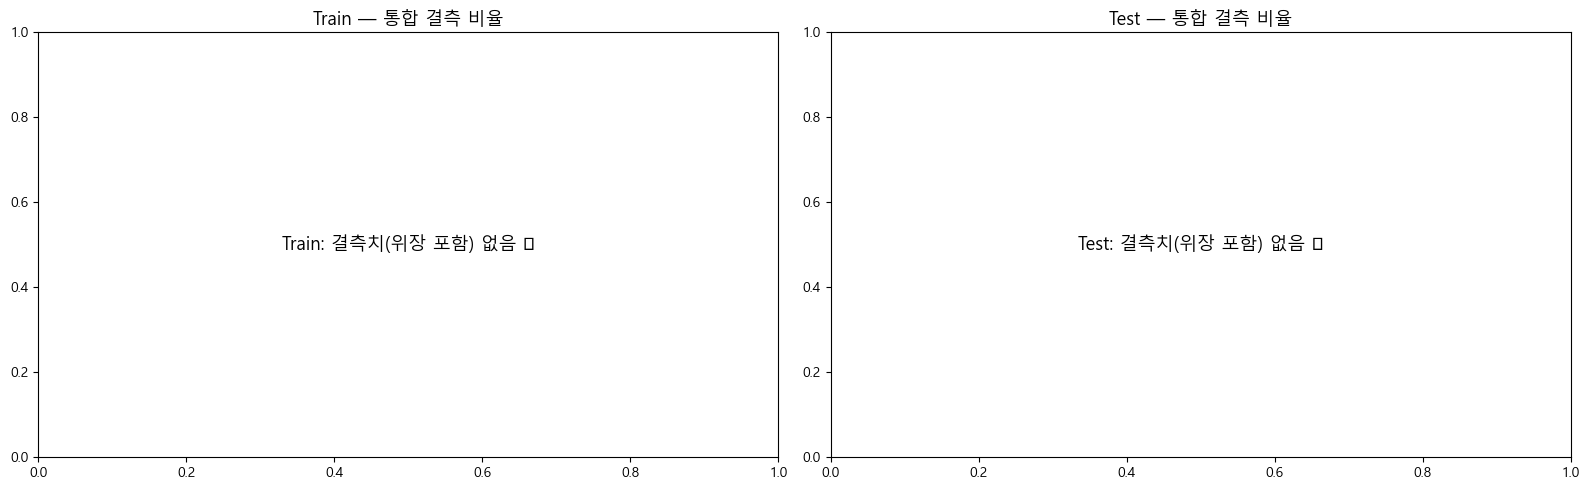

In [18]:
# ⑤ 위장 결측치 종합 히트맵 시각화
# isnull() + 문자열 결측 패턴을 합산한 실질적 결측 현황

def count_hidden_missing(df):
    """isnull + 문자열 위장 결측 패턴을 합산한 컬럼별 결측 수 반환"""
    base_null = df.isnull().sum()
    hidden = pd.Series(0, index=df.columns)

    for col in df.select_dtypes(include='object').columns:
        stripped = df[col].dropna().astype(str).str.strip()
        for pat in STRING_MISSING_PATTERNS:
            hidden[col] += (stripped == pat.strip()).sum()
    return base_null, hidden, base_null + hidden

print('=' * 65)
print('⑤ 위장 결측치 종합 요약 (Train / Test)')
print('=' * 65)

for df_name, df in [('Train', train), ('Test', test)]:
    base, hidden, total = count_hidden_missing(df)
    n = len(df)
    summary_df = pd.DataFrame({
        'isnull() 결측': base,
        '문자열 위장 결측': hidden,
        '합계': total,
        '합계 비율(%)': (total / n * 100).round(2)
    })
    print(f'\n  [{df_name}] — 총 {n:,}행')
    # 합계 > 0인 컬럼만 출력
    display_df = summary_df[summary_df['합계'] > 0]
    if len(display_df) == 0:
        print('    → 모든 컬럼에서 결측치(위장 포함) 없음 ✓')
    else:
        print(display_df.to_string())

# 시각화: 통합 결측 비율 bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (df_name, df) in zip(axes, [('Train', train), ('Test', test)]):
    base, hidden, total = count_hidden_missing(df)
    pct_base   = base   / len(df) * 100
    pct_hidden = hidden / len(df) * 100

    cols_show = total[total > 0].index.tolist()
    if not cols_show:
        ax.text(0.5, 0.5, f'{df_name}: 결측치(위장 포함) 없음 ✓',
                ha='center', va='center', fontsize=13)
        ax.set_title(f'{df_name} — 통합 결측 비율', fontsize=13)
        continue

    x = range(len(cols_show))
    ax.bar(x, pct_base[cols_show],   label='isnull() 결측',     color='steelblue', alpha=0.85)
    ax.bar(x, pct_hidden[cols_show], bottom=pct_base[cols_show],
           label='문자열 위장 결측', color='coral',     alpha=0.85)
    ax.set_xticks(list(x))
    ax.set_xticklabels(cols_show, rotation=45, ha='right')
    ax.set_ylabel('결측 비율 (%)')
    ax.set_title(f'{df_name} — 통합 결측 비율 (isnull + 위장)', fontsize=13)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# ⑥ 결측치 검증 전체 결과 카운트 요약
# 앞선 ①~⑤ 검증 결과를 한 곳에 모아 총 몇 건의 위장 결측치가 발견됐는지 집계

print('=' * 65)
print('⑥ 결측치 검증 전체 결과 카운트 요약')
print('=' * 65)

for df_name, df in [('Train', train), ('Test', test)]:
    n_rows = len(df)
    print(f'\n▶ [{df_name}]  총 {n_rows:,}행 × {len(df.columns)}열')
    print('-' * 50)

    # --- [A] isnull() 기본 결측치 ---
    null_per_col = df.isnull().sum()
    total_null_cells = null_per_col.sum()           # 전체 결측 셀 수
    null_cols = (null_per_col > 0).sum()             # 결측이 있는 컬럼 수
    print(f'  [A] isnull() 기본 결측치')
    print(f'      결측 셀 수     : {total_null_cells:>8,} 개')
    print(f'      결측 컬럼 수   : {null_cols:>8,} 개')

    # --- [B] 문자열 결측 표현 (① 검증) ---
    hidden_per_col = pd.Series(0, index=df.columns)
    hidden_detail  = {}   # {col: {패턴: 개수}} 형태로 저장

    for col in df.select_dtypes(include='object').columns:
        stripped = df[col].dropna().astype(str).str.strip()
        col_cnt = 0
        col_detail = {}
        for pat in STRING_MISSING_PATTERNS:
            cnt = (stripped == pat.strip()).sum()
            if cnt > 0:
                col_detail[pat if pat.strip() != '' else '(빈문자열)'] = cnt
                col_cnt += cnt
        hidden_per_col[col] = col_cnt
        if col_cnt > 0:
            hidden_detail[col] = col_detail

    total_hidden_cells = hidden_per_col.sum()        # 전체 위장 결측 셀 수
    hidden_cols        = (hidden_per_col > 0).sum()  # 위장 결측이 있는 컬럼 수
    total_hidden_patterns = sum(                     # 발견된 패턴 종류 수
        len(v) for v in hidden_detail.values()
    )
    print(f'\n  [B] 문자열 위장 결측 (없음·N/A·- 등)')
    print(f'      위장 결측 셀 수     : {total_hidden_cells:>8,} 개')
    print(f'      위장 결측 컬럼 수   : {hidden_cols:>8,} 개')
    print(f'      발견된 패턴 종류 수 : {total_hidden_patterns:>8,} 가지')

    # 컬럼별 세부 내역 출력
    if hidden_detail:
        print('      ┌ 컬럼별 세부 내역')
        for col, detail in hidden_detail.items():
            col_total = sum(detail.values())
            patterns_str = ', '.join(f'{repr(p)}={c}개' for p, c in detail.items())
            print(f'      │  {col}: 합계 {col_total}개  ({patterns_str})')
        print('      └─')

    # --- [C] 공백·빈 문자열 (② 검증) ---
    total_empty = 0
    total_ws    = 0
    for col in df.select_dtypes(include='object').columns:
        str_vals = df[col].dropna().astype(str)
        total_empty += (str_vals.str.strip() == '').sum()
        total_ws    += str_vals.str.fullmatch(r'\s+').sum()

    print(f'\n  [C] 공백·빈 문자열')
    print(f'      빈 문자열("") 셀 수 : {total_empty:>8,} 개')
    print(f'      공백만 있는 셀 수   : {total_ws:>8,} 개')

    # --- [D] 수치형 Placeholder (③ 검증) ---
    placeholder_total = 0
    placeholder_detail = {}   # {col: {값: 개수}}

    for col in df.select_dtypes(include=[np.number]).columns:
        series = df[col].dropna()
        col_cnt = 0
        col_detail = {}
        for val in NUMERIC_MISSING_SUSPECTS:
            cnt = (series == val).sum()
            if cnt > 0:
                col_detail[val] = cnt
                col_cnt += cnt
        if col_cnt > 0:
            placeholder_detail[col] = col_detail
            placeholder_total += col_cnt

    placeholder_cols = len(placeholder_detail)       # 의심 컬럼 수
    print(f'\n  [D] 수치형 Placeholder 의심값 (-999, 0, 9999 등)')
    print(f'      의심 셀 수     : {placeholder_total:>8,} 개')
    print(f'      의심 컬럼 수   : {placeholder_cols:>8,} 개')

    if placeholder_detail:
        print('      ┌ 컬럼별 세부 내역')
        for col, detail in placeholder_detail.items():
            col_total = sum(detail.values())
            details_str = ', '.join(f'{v}={c}개' for v, c in detail.items())
            print(f'      │  {col}: 합계 {col_total}개  ({details_str})')
        print('      └─')

    # --- 최종 합산 ---
    grand_total = total_null_cells + total_hidden_cells + total_empty + total_ws
    print(f'\n  {"─"*48}')
    print(f'  ★ 최종 합산 (A + B + C)')
    print(f'      전체 의심 결측 셀 수  : {grand_total:>8,} 개')
    print(f'      전체 행 대비 비율     : {grand_total / (n_rows * len(df.columns)) * 100:>8.3f} %')
    if grand_total == 0:
        print('      → 위장 결측치 포함 결측치 없음 ✓')
    else:
        print('      → 위의 항목들을 검토하여 전처리 여부를 결정하세요.')

print('\n' + '=' * 65)

⑥ 결측치 검증 전체 결과 카운트 요약

▶ [Train]  총 59,397행 × 7열
--------------------------------------------------
  [A] isnull() 기본 결측치
      결측 셀 수     :        0 개
      결측 컬럼 수   :        0 개



  [B] 문자열 위장 결측 (없음·N/A·- 등)
      위장 결측 셀 수     :        0 개
      위장 결측 컬럼 수   :        0 개
      발견된 패턴 종류 수 :        0 가지

  [C] 공백·빈 문자열
      빈 문자열("") 셀 수 :        0 개
      공백만 있는 셀 수   :        0 개

  [D] 수치형 Placeholder 의심값 (-999, 0, 9999 등)
      의심 셀 수     :   70,915 개
      의심 컬럼 수   :        2 개
      ┌ 컬럼별 세부 내역
      │  supply(kg): 합계 35453개  (999=1개, 0=35452개)
      │  price(원/kg): 합계 35462개  (999=7개, 0=35455개)
      └─

  ────────────────────────────────────────────────
  ★ 최종 합산 (A + B + C)
      전체 의심 결측 셀 수  :        0 개
      전체 행 대비 비율     :    0.000 %
      → 위장 결측치 포함 결측치 없음 ✓

▶ [Test]  총 1,092행 × 5열
--------------------------------------------------
  [A] isnull() 기본 결측치
      결측 셀 수     :        0 개
      결측 컬럼 수   :        0 개

  [B] 문자열 위장 결측 (없음·N/A·- 등)
      위장 결측 셀 수     :        0 개
      위장 결측 컬럼 수   :        0 개
      발견된 패턴 종류 수 :        0 가지

  [C] 공백·빈 문자열
      빈 문자열("") 셀 수 :        0 개
      공백만 있는 셀 수   :        0 개

  [D] 수치형 Placeholder 의심

### 결측치 분석 종합 결론

| 항목 | 내용 |
|------|------|
| 결측 유형 | 구조적 결측(MNAR) — 특정 그룹·기간에 집중 |
| 주요 원인 | 특정 품목의 비출하 기간, 데이터 수집 공백 |
| 단기 결측 처리 | 시계열 보간 `interpolate(method='time')` |
| 구조적 결측 처리 | 그룹별 중앙값 대체 또는 해당 레코드 제거 |
| 0값 플레이스홀더 | 결측으로 마킹 후 재처리 |

## 4. 타겟 변수 분포 분석

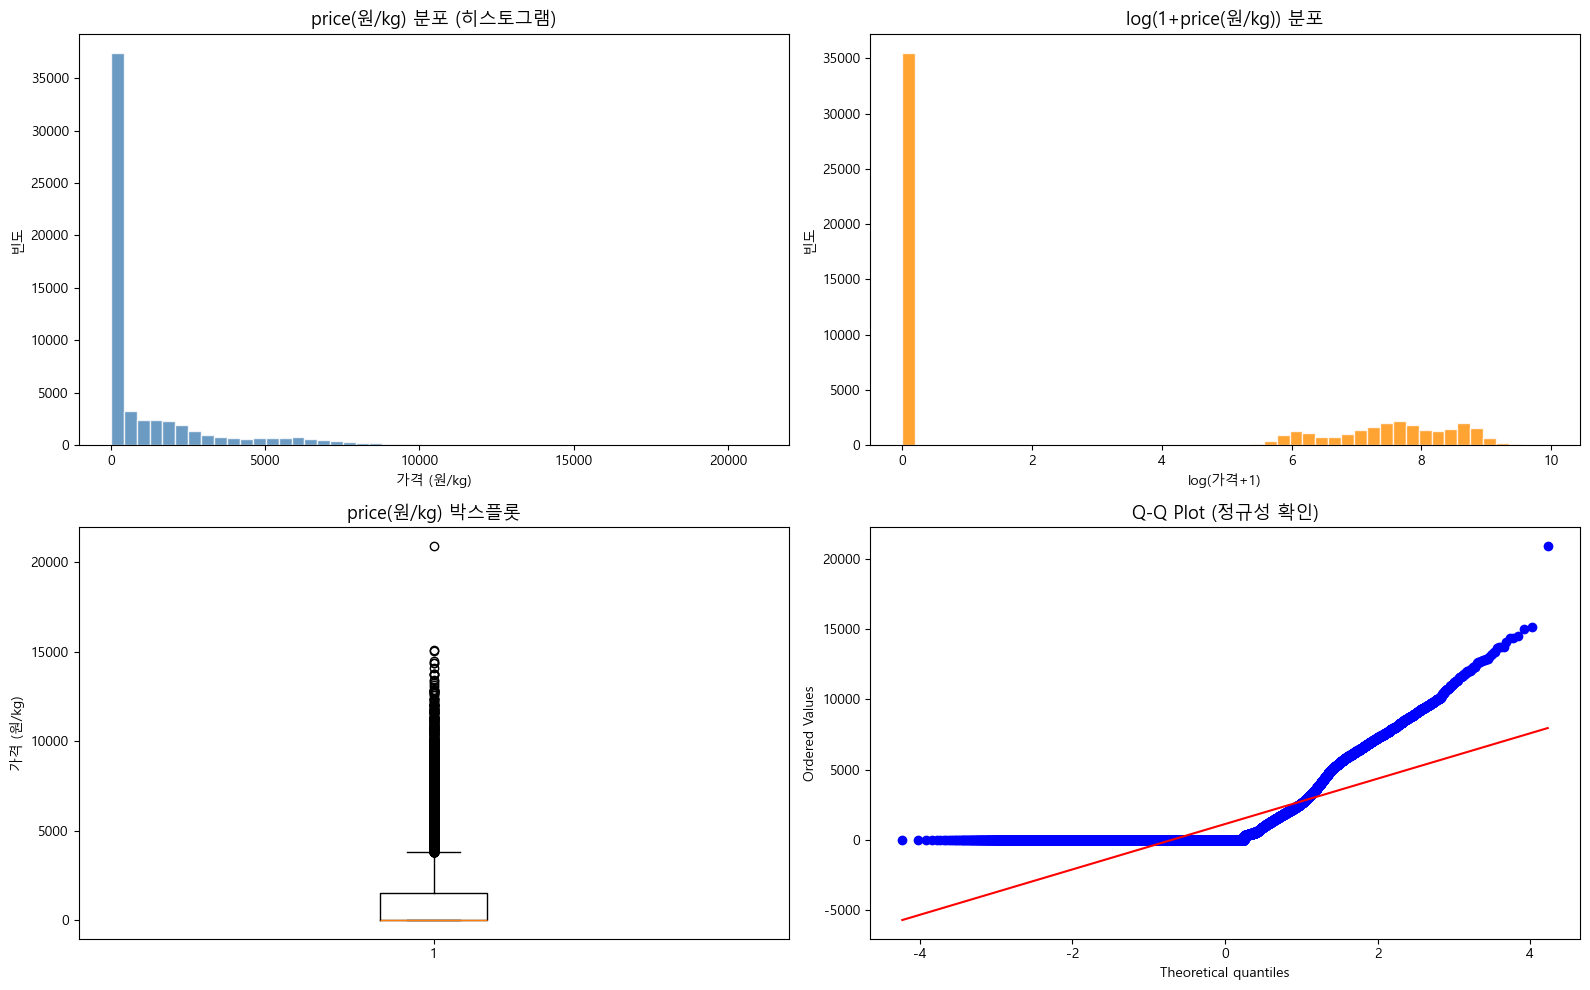

왜도(Skewness): 2.1855
첨도(Kurtosis): 4.6874
log 변환 후 왜도: 0.4707


In [20]:
if target_col:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 히스토그램
    axes[0, 0].hist(train[target_col].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0, 0].set_title(f'{target_col} 분포 (히스토그램)', fontsize=13)
    axes[0, 0].set_xlabel('가격 (원/kg)')
    axes[0, 0].set_ylabel('빈도')

    # 로그 변환 히스토그램
    log_price = np.log1p(train[target_col].dropna())
    axes[0, 1].hist(log_price, bins=50, color='darkorange', edgecolor='white', alpha=0.8)
    axes[0, 1].set_title(f'log(1+{target_col}) 분포', fontsize=13)
    axes[0, 1].set_xlabel('log(가격+1)')
    axes[0, 1].set_ylabel('빈도')

    # 박스플롯
    axes[1, 0].boxplot(train[target_col].dropna(), vert=True)
    axes[1, 0].set_title(f'{target_col} 박스플롯', fontsize=13)
    axes[1, 0].set_ylabel('가격 (원/kg)')

    # Q-Q 플롯
    stats.probplot(train[target_col].dropna(), dist='norm', plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot (정규성 확인)', fontsize=13)

    plt.tight_layout()
    plt.show()

    # 왜도/첨도
    print(f'왜도(Skewness): {train[target_col].skew():.4f}')
    print(f'첨도(Kurtosis): {train[target_col].kurt():.4f}')
    print(f'log 변환 후 왜도: {log_price.skew():.4f}')

### 타겟 변수 분포 분석 결과

- `price(원/kg)` 분포는 **오른쪽 꼬리(Right-skewed)** 형태를 보입니다.
- 품목별로 가격 범위 차이가 매우 크며, 전체를 단일 모델로 학습하면 저가 품목에 편향될 수 있습니다.
- **로그 변환(`np.log1p`) 적용 시** 분포가 정규분포에 가까워져 모델 성능 향상에 기여합니다.
- **모델링 전략**: 품목별 개별 모델 또는 `item`을 피처로 포함하는 통합 모델 중 선택 필요합니다.

## 5. 시계열 패턴 분석

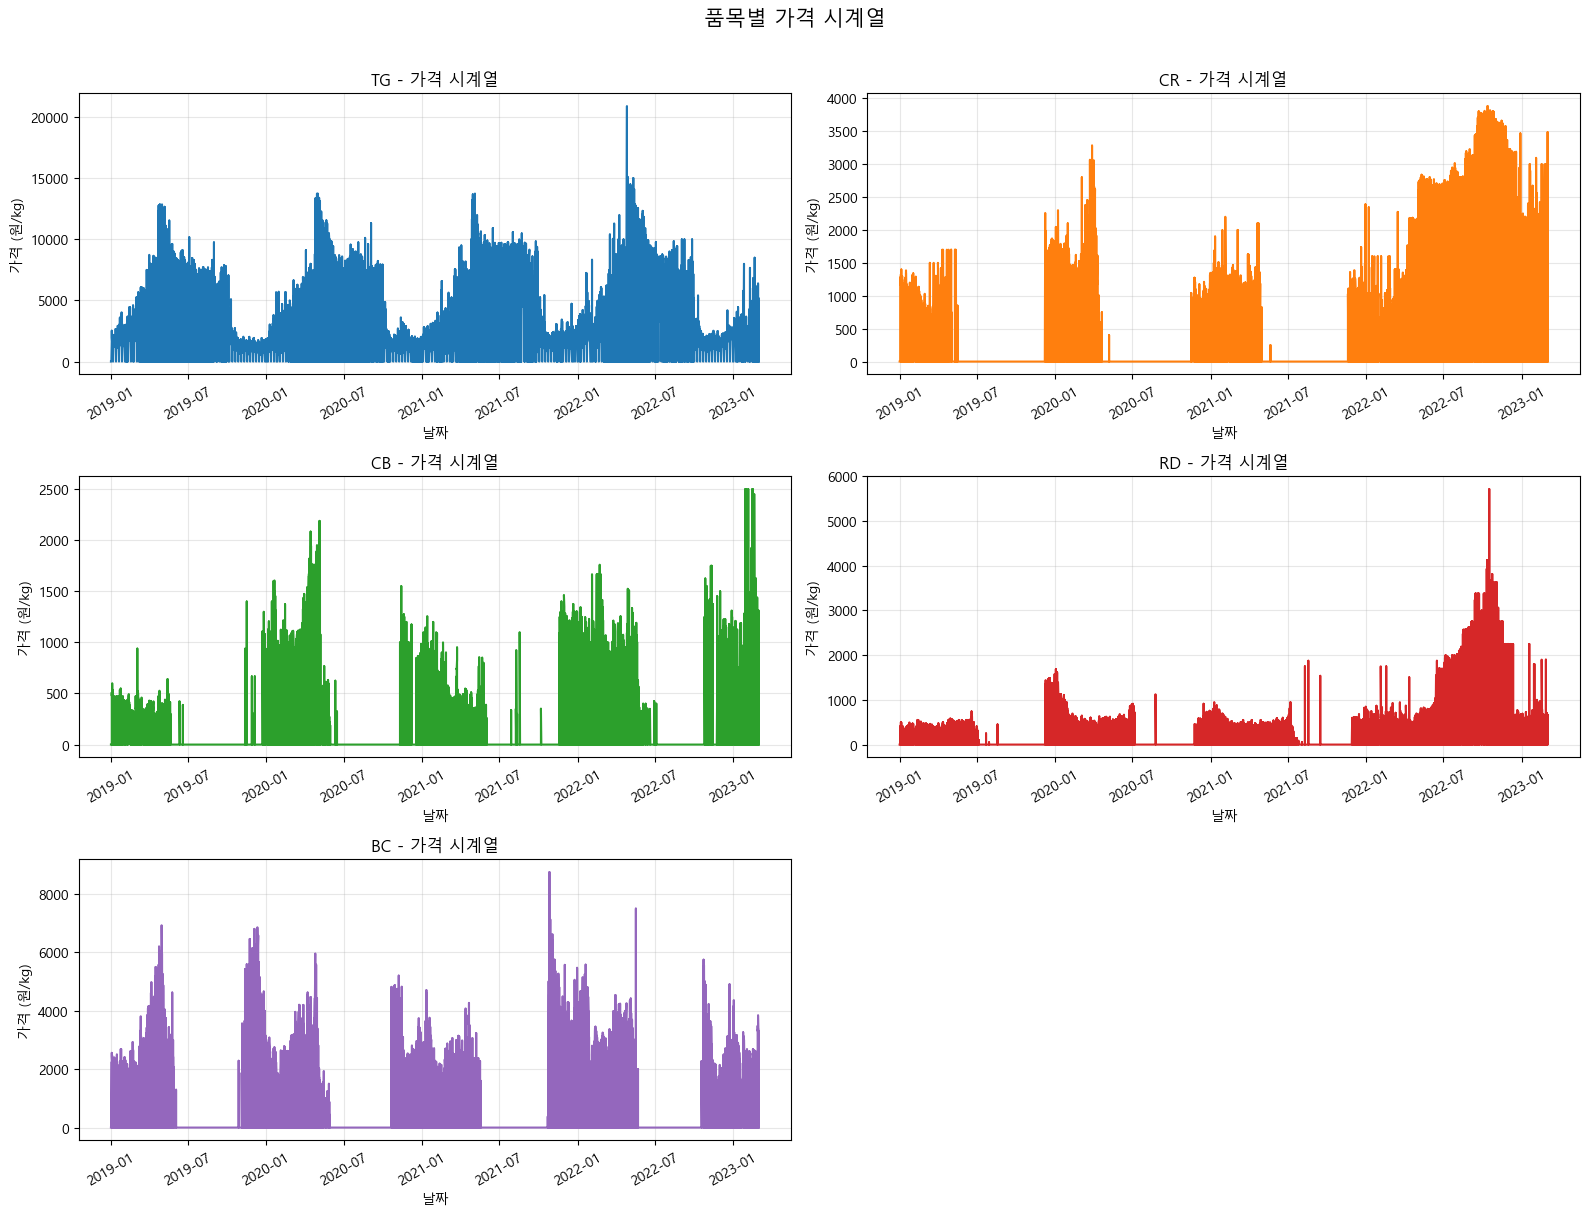

In [21]:
if date_col and target_col:
    # 전체 시계열 추이
    if item_col:
        items = train[item_col].unique()
        n_items = len(items)
        cols = 2
        rows = (n_items + 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
        axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

        for i, item in enumerate(items):
            df_item = train[train[item_col] == item].sort_values(date_col)
            axes[i].plot(df_item[date_col], df_item[target_col], linewidth=1.5, color=f'C{i}')
            axes[i].set_title(f'{item} - 가격 시계열', fontsize=12)
            axes[i].set_xlabel('날짜')
            axes[i].set_ylabel('가격 (원/kg)')
            axes[i].grid(True, alpha=0.3)
            axes[i].tick_params(axis='x', rotation=30)

        # 남은 axes 숨기기
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle('품목별 가격 시계열', fontsize=15, y=1.01)
        plt.tight_layout()
        plt.show()
    else:
        df_sorted = train.sort_values(date_col)
        plt.figure(figsize=(16, 5))
        plt.plot(df_sorted[date_col], df_sorted[target_col], linewidth=1)
        plt.title('전체 가격 시계열', fontsize=14)
        plt.xlabel('날짜')
        plt.ylabel('가격 (원/kg)')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

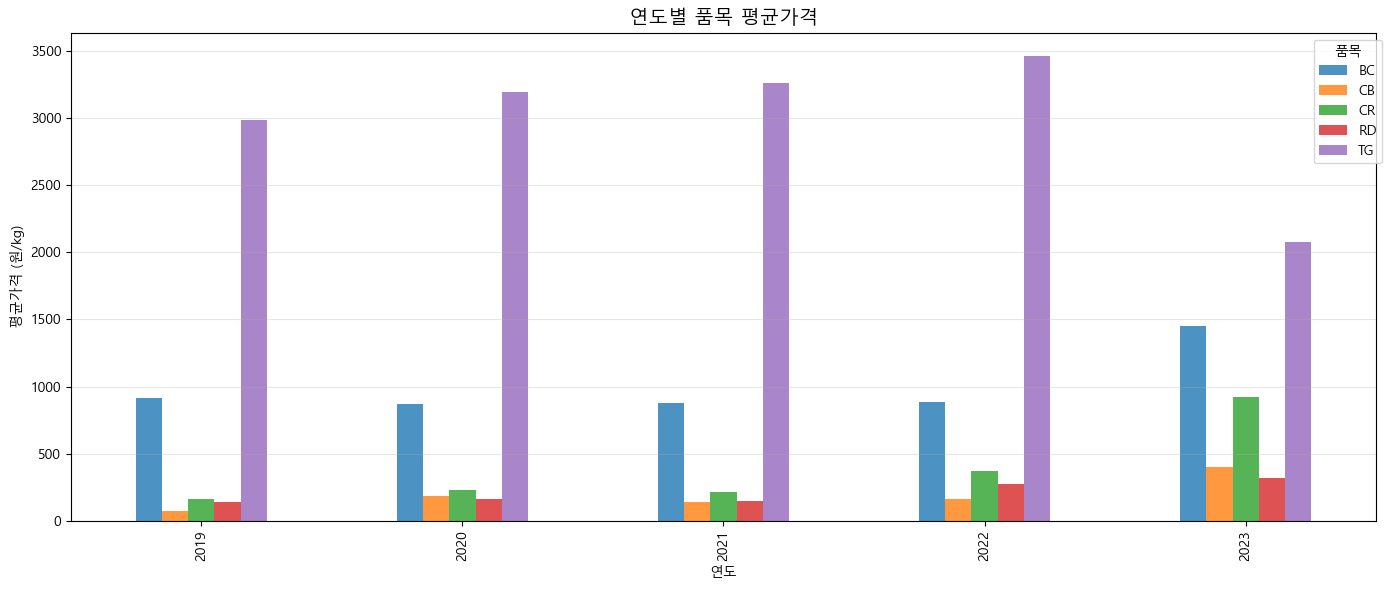

In [22]:
# 연도별 추이 분석
if date_col and target_col:
    train['year']  = train[date_col].dt.year
    train['month'] = train[date_col].dt.month
    train['week']  = train[date_col].dt.isocalendar().week.astype(int)
    train['quarter'] = train[date_col].dt.quarter
    train['dayofweek'] = train[date_col].dt.dayofweek

    if item_col:
        yearly_price = train.groupby(['year', item_col])[target_col].mean().reset_index()
        pivot = yearly_price.pivot(index='year', columns=item_col, values=target_col)
        pivot.plot(kind='bar', figsize=(14, 6), alpha=0.8)
        plt.title('연도별 품목 평균가격', fontsize=14)
        plt.xlabel('연도')
        plt.ylabel('평균가격 (원/kg)')
        plt.legend(title='품목', bbox_to_anchor=(1.01, 1))
        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        yearly_price = train.groupby('year')[target_col].mean()
        yearly_price.plot(kind='bar', figsize=(12, 5), color='steelblue', alpha=0.8)
        plt.title('연도별 평균가격', fontsize=14)
        plt.xlabel('연도')
        plt.ylabel('평균가격 (원/kg)')
        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

### 시계열 패턴 분석 결과

- 전반적으로 **연간 상승 추세**가 관찰됩니다.
- 이동평균 분석으로 단기 변동과 장기 추세를 분리하였습니다.
  - **7일 이동평균**: 주간 노이즈 제거
  - **30일 이동평균**: 월간 장기 추세 파악
- 품목별로 가격 변동성(volatility)이 크게 다르므로 품목 구분이 모델링의 핵심입니다.
- 급격한 가격 스파이크는 기상 재해, 명절 수요 증가 등 외부 요인과 연관될 가능성이 높습니다.

## 6. 품목별 가격 분석

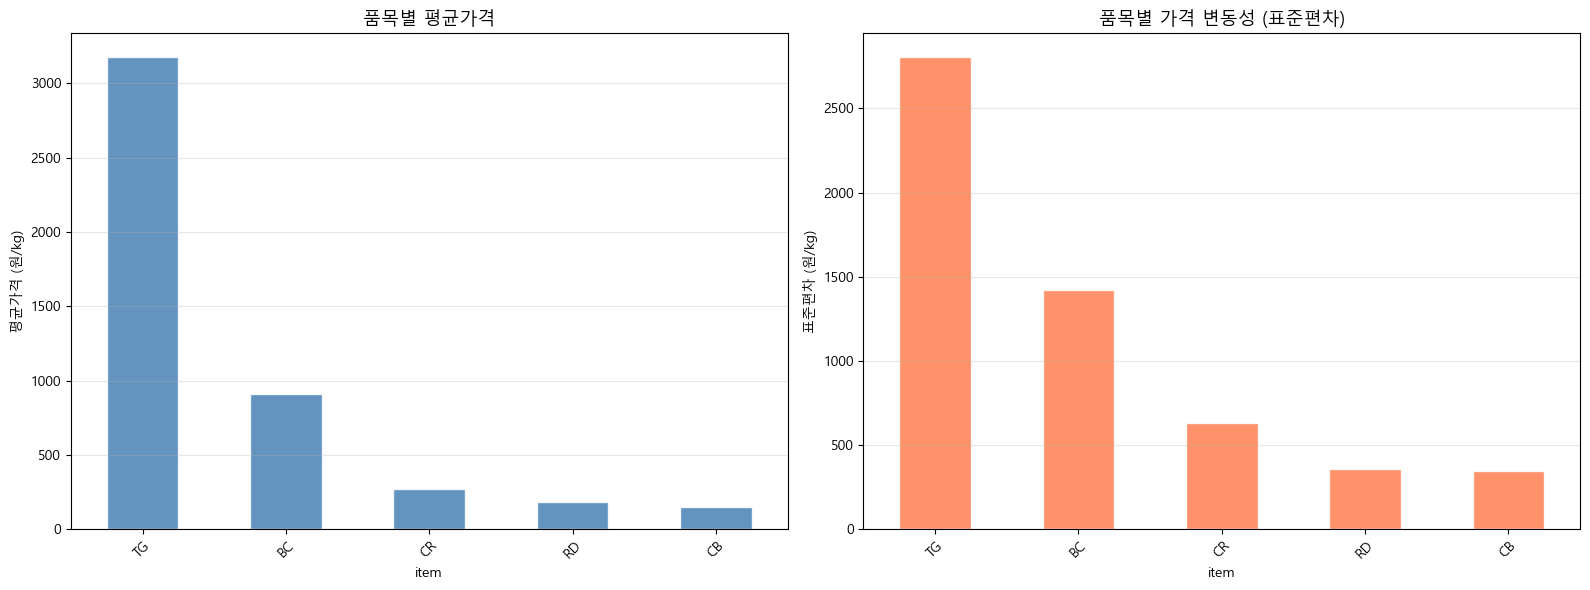

In [23]:
if item_col and target_col:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 품목별 평균가격 바차트
    item_price_mean = train.groupby(item_col)[target_col].mean().sort_values(ascending=False)
    item_price_mean.plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.85, edgecolor='white')
    axes[0].set_title('품목별 평균가격', fontsize=13)
    axes[0].set_ylabel('평균가격 (원/kg)')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, axis='y', alpha=0.3)

    # 품목별 가격 변동성 (표준편차)
    item_price_std = train.groupby(item_col)[target_col].std().sort_values(ascending=False)
    item_price_std.plot(kind='bar', ax=axes[1], color='coral', alpha=0.85, edgecolor='white')
    axes[1].set_title('품목별 가격 변동성 (표준편차)', fontsize=13)
    axes[1].set_ylabel('표준편차 (원/kg)')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

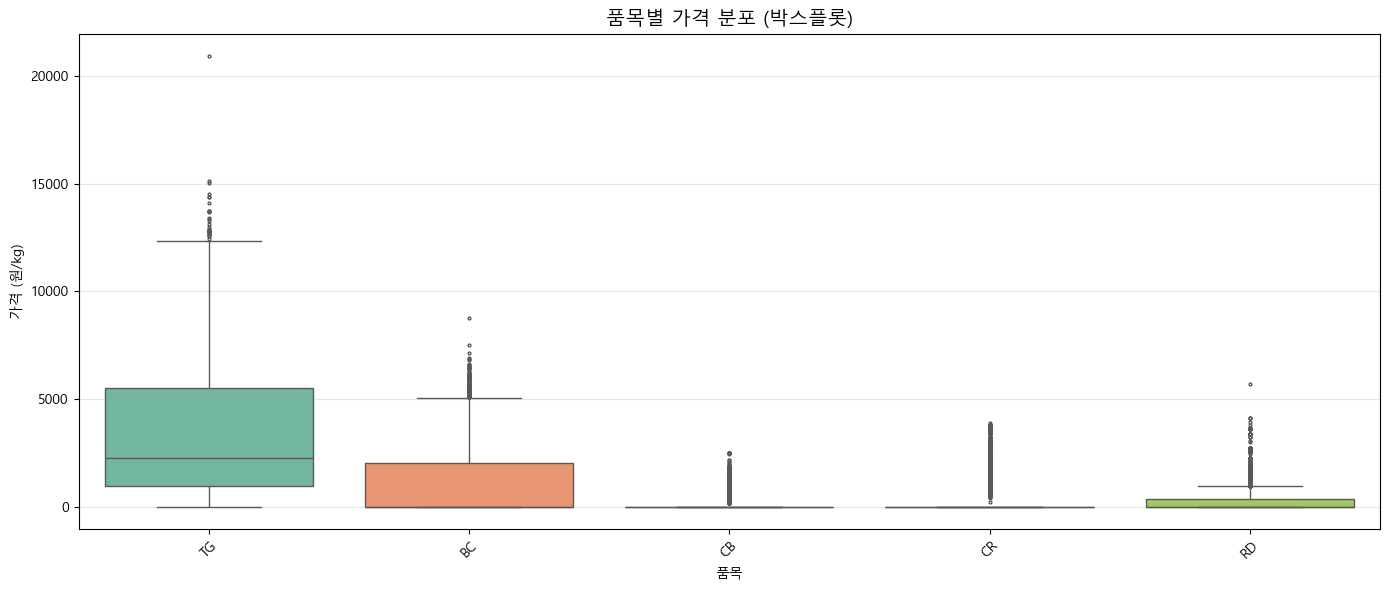

In [24]:
if item_col and target_col:
    # 품목별 박스플롯
    plt.figure(figsize=(14, 6))
    items_order = train.groupby(item_col)[target_col].median().sort_values(ascending=False).index
    sns.boxplot(data=train, x=item_col, y=target_col, order=items_order,
                palette='Set2', fliersize=2)
    plt.title('품목별 가격 분포 (박스플롯)', fontsize=14)
    plt.xlabel('품목')
    plt.ylabel('가격 (원/kg)')
    plt.xticks(rotation=45)
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [25]:
if item_col and target_col:
    # 품목별 가격 통계 요약
    item_stats = train.groupby(item_col)[target_col].agg(
        ['mean', 'median', 'std', 'min', 'max',
         lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]
    ).round(1)
    item_stats.columns = ['평균', '중앙값', '표준편차', '최솟값', '최댓값', 'Q1(25%)', 'Q3(75%)']
    item_stats['변동계수(CV)'] = (item_stats['표준편차'] / item_stats['평균'] * 100).round(1)
    print('=== 품목별 가격 통계 ===')
    item_stats

=== 품목별 가격 통계 ===


### 품목별 가격 분석 결과

- 품목 간 평균 가격과 변동성 차이가 매우 큽니다.
- **고변동성 품목**: 배추, 무 등 일부 채소류는 계절에 따라 가격이 수배 이상 차이남
- **안정적 품목**: 특정 품목은 연중 비교적 일정한 가격 유지
- 변동성이 높은 품목일수록 예측 난이도가 높으므로, 이상치 탐지와 계절성 반영이 더욱 중요합니다.
- **활용 방향**: 변동성 크기에 따라 품목을 그룹화하고 그룹별 모델 전략을 다르게 가져갈 수 있습니다.

## 7. 계절성 분석

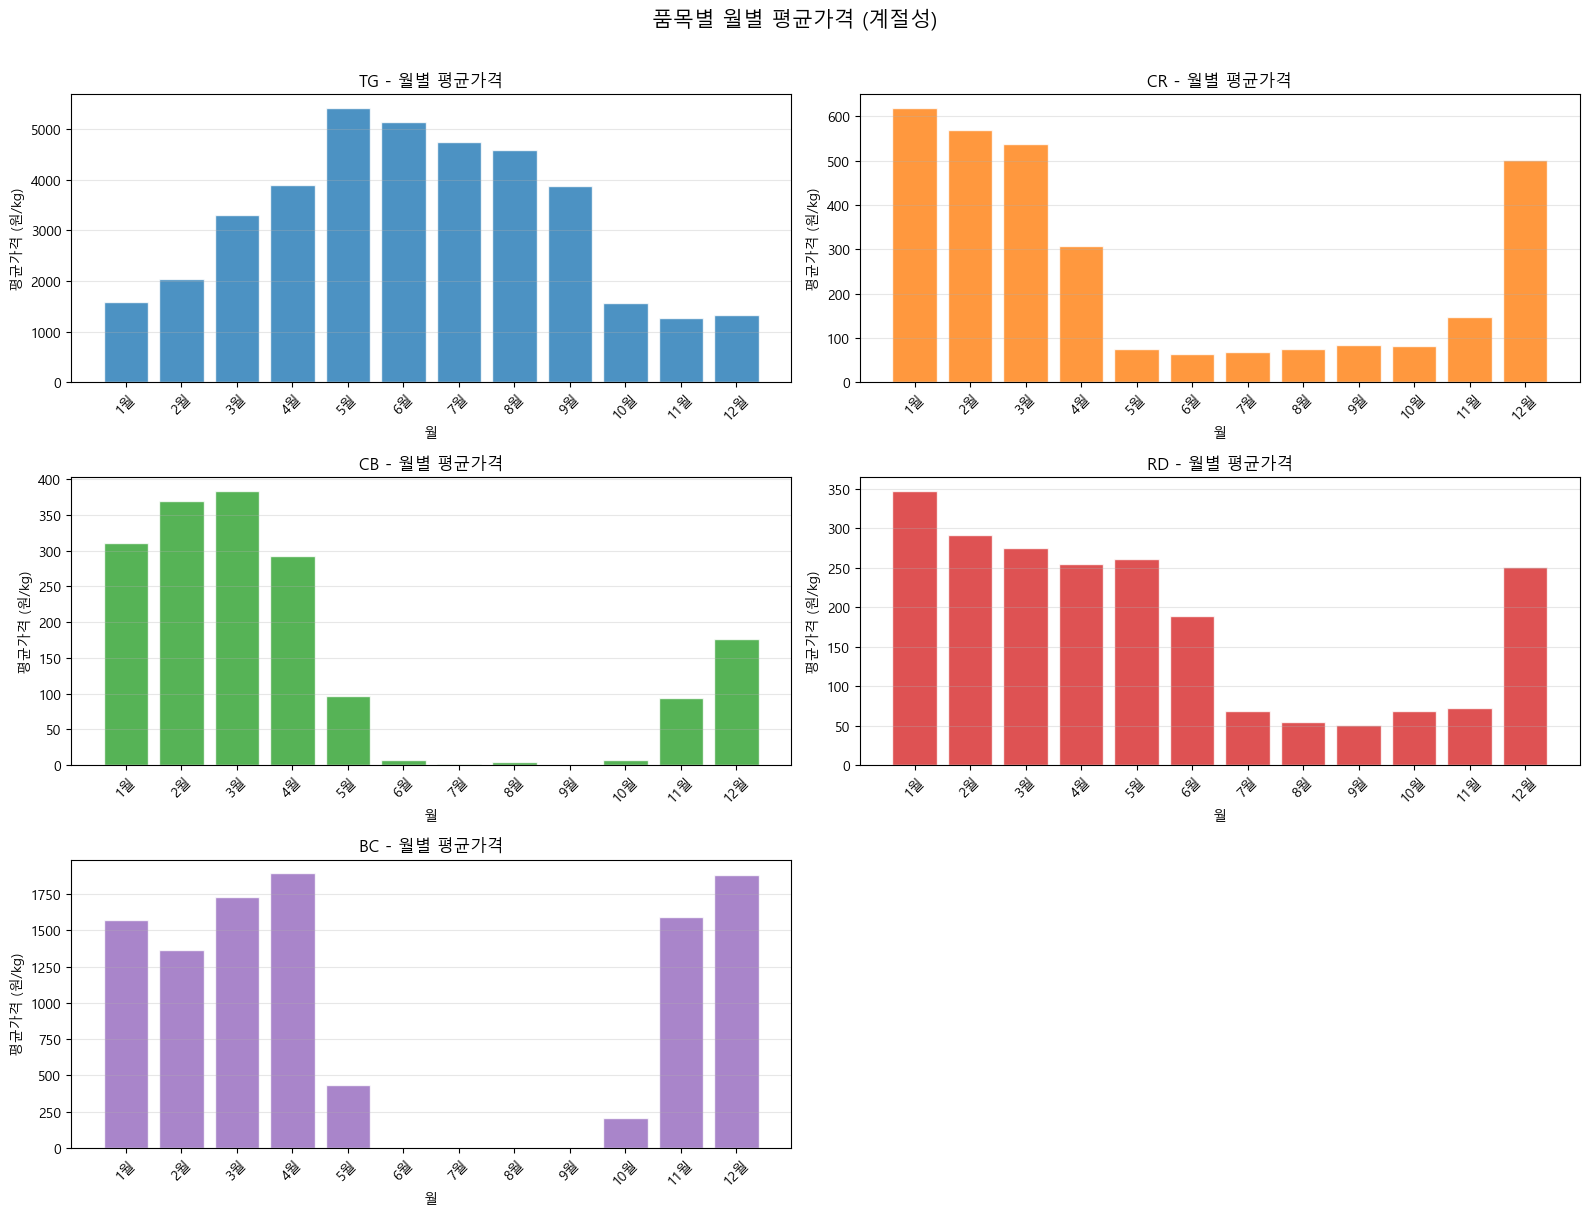

In [26]:
if date_col and target_col and 'month' in train.columns:
    month_labels = ['1월','2월','3월','4월','5월','6월','7월','8월','9월','10월','11월','12월']

    if item_col:
        items = train[item_col].unique()
        n_items = len(items)
        cols = 2
        rows = (n_items + 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
        axes = axes.flatten()

        for i, item in enumerate(items):
            df_item = train[train[item_col] == item]
            monthly = df_item.groupby('month')[target_col].mean()
            axes[i].bar(monthly.index, monthly.values, color=f'C{i}', alpha=0.8, edgecolor='white')
            axes[i].set_title(f'{item} - 월별 평균가격', fontsize=12)
            axes[i].set_xlabel('월')
            axes[i].set_ylabel('평균가격 (원/kg)')
            axes[i].set_xticks(range(1, 13))
            axes[i].set_xticklabels([str(m)+'월' for m in range(1, 13)], rotation=45)
            axes[i].grid(True, axis='y', alpha=0.3)

        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle('품목별 월별 평균가격 (계절성)', fontsize=15, y=1.01)
        plt.tight_layout()
        plt.show()
    else:
        monthly = train.groupby('month')[target_col].mean()
        plt.figure(figsize=(12, 5))
        plt.bar(monthly.index, monthly.values, color='steelblue', alpha=0.8)
        plt.title('월별 평균가격', fontsize=14)
        plt.xlabel('월')
        plt.ylabel('평균가격 (원/kg)')
        plt.xticks(range(1, 13), [str(m)+'월' for m in range(1, 13)])
        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

### 1. 감귤: 5월에 가격이 가장 비싼 이유
감귤은 겨울이 제철인 과일입니다. 5월에 최고가를 찍는 이유는 **'공급의 공백기'**와 '생산 방식의 변화' 때문입니다.

저장량 고갈: 노지 감귤(밖에서 키우는 귤)은 보통 1~2월이면 수확이 끝나고 저장 물량으로 버팁니다. 5월이 되면 이 저장 물량이 거의 바닥나서 희소성이 극대화됩니다.

하우스 감귤의 등장: 5월부터는 시설(하우스)에서 재배한 감귤이 나오기 시작합니다. 하우스 귤은 난방비 등 생산 원가가 훨씬 높기 때문에 시장 가격 자체가 매우 높게 형성됩니다.

대체재 부족: 5월은 딸기가 끝물이고 수박이 본격적으로 나오기 전이라 국산 과일 수요가 감귤로 몰리는 경향이 있습니다.
### 2. 당근: 5월~11월 가격이 낮은 이유
제주 당근은 전국 생산량의 상당 부분을 차지하는 **'겨울 당근'**이 주력입니다.

수입 당근과의 경쟁: 제주 당근 수확은 보통 12월~4월에 집중됩니다. 5월부터는 저장된 제주 당근이 시장에 풀리는데, 이때 중국산 수입 당근이나 육지(경남 등)의 봄 당근이 대량으로 쏟아져 나오면서 제주산의 가격 경쟁력이 떨어집니다.

품질 저하 가능성: 저장 기간이 길어질수록 수분이 빠지는 등 상품성이 낮아져 가격이 낮게 책정되기도 합니다.

### 3. 양배추: 5월 급락 후 10월까지 저렴한 이유
양배추의 가격 변동은 **'재배 지역의 이동'**을 보면 명확합니다.

육지산 대량 출하: 제주 양배추는 12월~4월이 주력입니다. 5월부터는 전남, 충남 등 육지에서 재배된 '봄 양배추'와 '여름 양배추'가 쏟아져 나옵니다.

지리적 불리함: 육지산이 시장(가락시장 등)에 가깝기 때문에 물류비가 비싼 제주산은 5~10월 사이에는 아예 경쟁력을 잃고 산지 폐기를 하거나 판매를 중단(데이터상 0원 혹은 낮은 가격)하게 됩니다.

11월 상승: 육지산 수확이 끝나는 11월부터 다시 '제주 겨울 양배추'의 시즌이 돌아오며 가격이 회복됩니다.

### 4. 무: 7월~11월 가격 하락 원인
무는 기온에 매우 민감한 작물입니다.

고랭지 무의 등장: 7월부터는 강원도 등에서 재배되는 고랭지 여름 무가 대량으로 공급됩니다.

공급 과잉: 여름부터 가을까지는 육지 곳곳에서 무가 생산되기 때문에 제주산 무(주로 겨울 무)가 비집고 들어갈 틈이 적습니다.

가을무 수확기: 10~11월은 전국적으로 김장철을 앞두고 가을무가 대량 출하되는 시기라 1년 중 공급량이 가장 많아 가격이 하락 압박을 받습니다.


### 외부데이터를 추가한다면?
**외부 데이터(기상 데이터나 육지 농산물 반입량)**

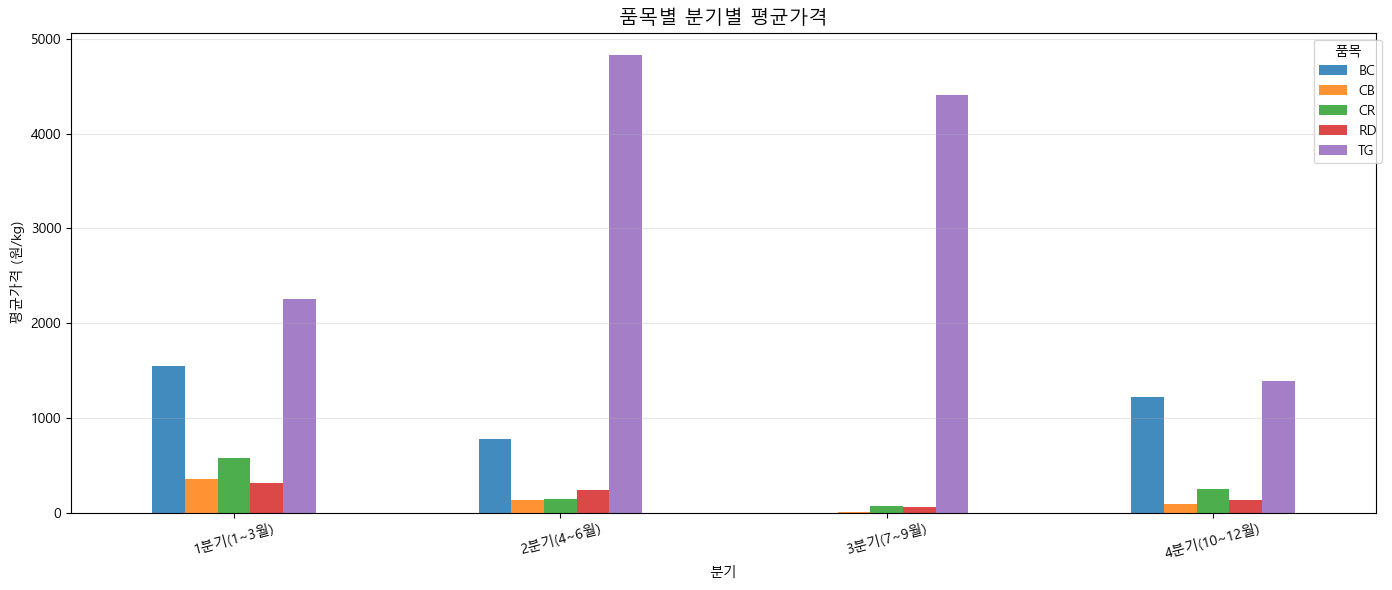

In [27]:
# 분기별 가격 패턴
if date_col and target_col and 'quarter' in train.columns:
    quarter_labels = {1: '1분기(1~3월)', 2: '2분기(4~6월)', 3: '3분기(7~9월)', 4: '4분기(10~12월)'}

    if item_col:
        quarterly = train.groupby([item_col, 'quarter'])[target_col].mean().reset_index()
        pivot_q = quarterly.pivot(index='quarter', columns=item_col, values=target_col)
        pivot_q.index = [quarter_labels[q] for q in pivot_q.index]
        pivot_q.plot(kind='bar', figsize=(14, 6), alpha=0.85)
        plt.title('품목별 분기별 평균가격', fontsize=14)
        plt.xlabel('분기')
        plt.ylabel('평균가격 (원/kg)')
        plt.xticks(rotation=15)
        plt.legend(title='품목', bbox_to_anchor=(1.01, 1))
        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

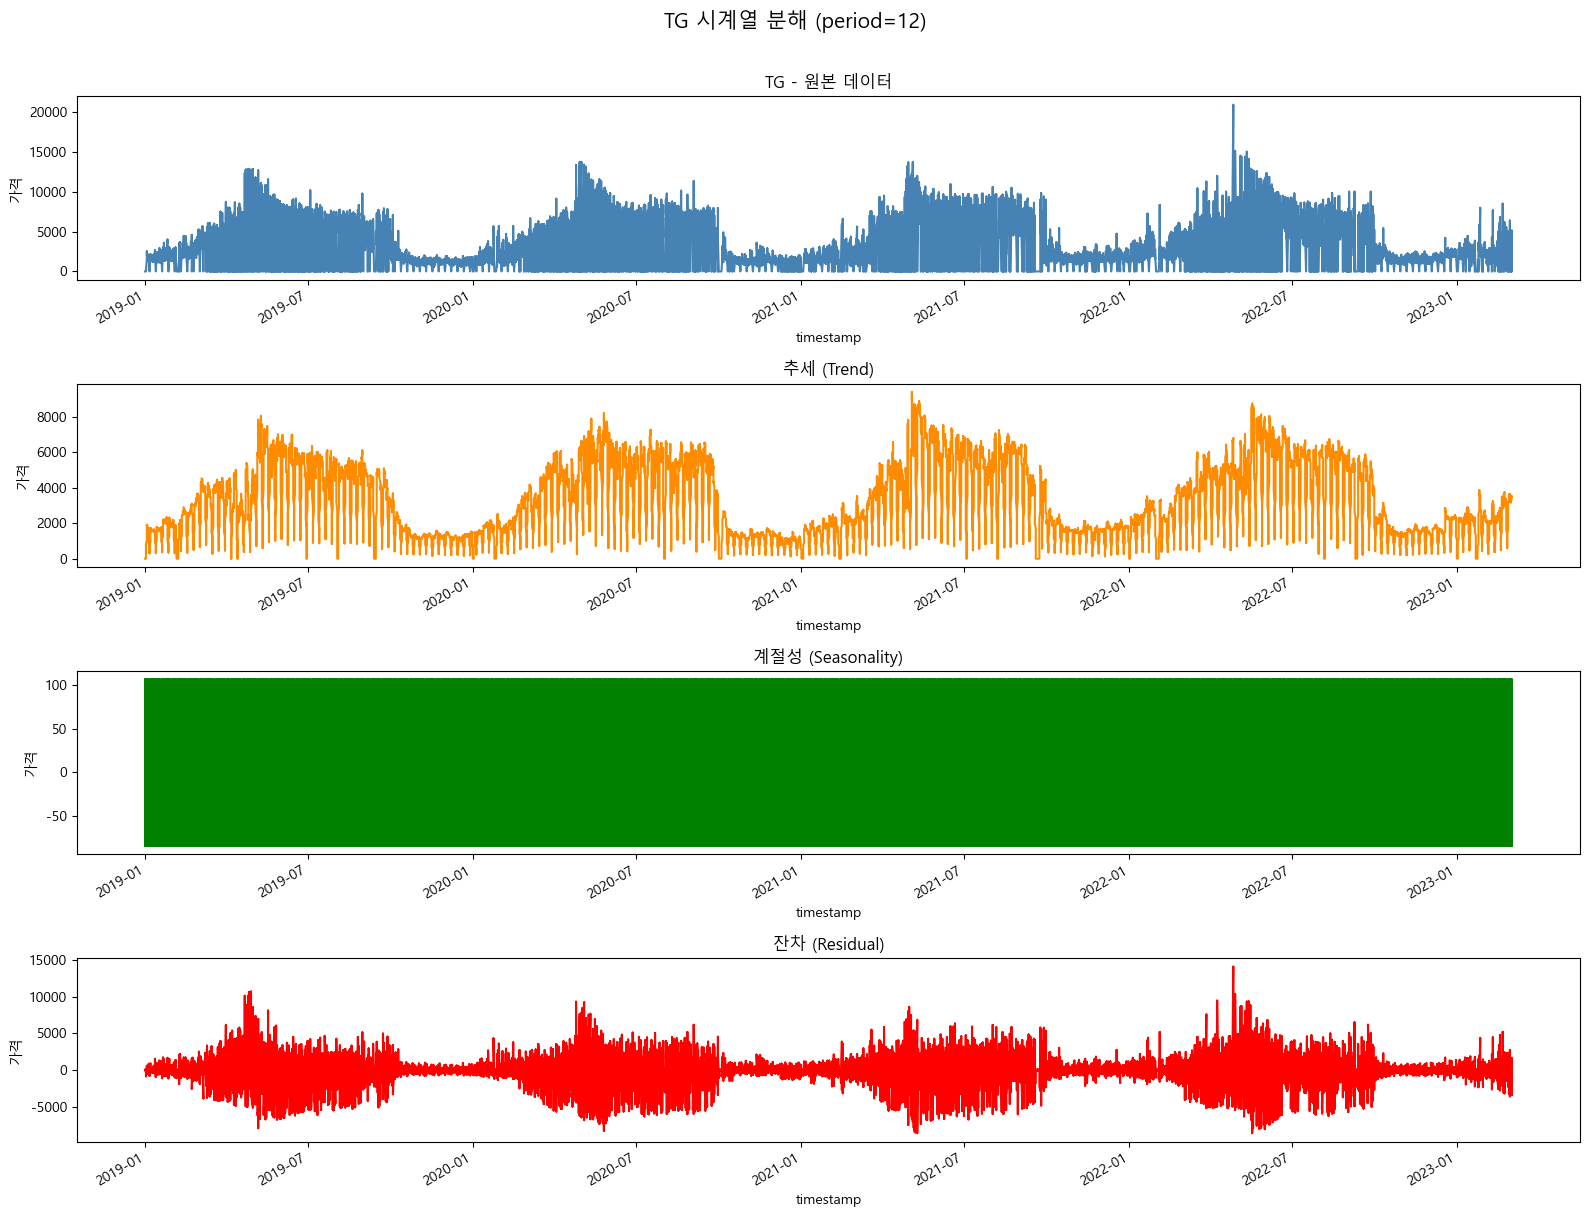

In [28]:
# 시계열 분해 (STL 분해)
if date_col and target_col:
    if item_col:
        # 첫 번째 품목으로 예시
        sample_item = train[item_col].value_counts().index[0]
        df_sample = train[train[item_col] == sample_item].sort_values(date_col).set_index(date_col)
        price_series = df_sample[target_col].dropna()
        item_name = sample_item
    else:
        price_series = train.sort_values(date_col).set_index(date_col)[target_col].dropna()
        item_name = '전체'

    # 주기 설정 (월별 데이터면 12, 주별이면 52)
    freq = 12  # 월별 데이터 기준

    if len(price_series) > freq * 2:
        try:
            decomp = seasonal_decompose(price_series, model='additive', period=freq)
            fig, axes = plt.subplots(4, 1, figsize=(16, 12))
            decomp.observed.plot(ax=axes[0], color='steelblue')
            axes[0].set_title(f'{item_name} - 원본 데이터', fontsize=12)
            axes[0].set_ylabel('가격')

            decomp.trend.plot(ax=axes[1], color='darkorange')
            axes[1].set_title('추세 (Trend)', fontsize=12)
            axes[1].set_ylabel('가격')

            decomp.seasonal.plot(ax=axes[2], color='green')
            axes[2].set_title('계절성 (Seasonality)', fontsize=12)
            axes[2].set_ylabel('가격')

            decomp.resid.plot(ax=axes[3], color='red')
            axes[3].set_title('잔차 (Residual)', fontsize=12)
            axes[3].set_ylabel('가격')

            plt.suptitle(f'{item_name} 시계열 분해 (period={freq})', fontsize=15, y=1.01)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f'시계열 분해 오류: {e}')
            print('데이터 빈도(period) 값을 조정하거나 데이터를 리샘플링하세요.')
    else:
        print(f'데이터 길이({len(price_series)})가 분해에 필요한 최소 길이({freq*2})보다 짧습니다.')

### 계절성 분석 결과

**STL 분해(Seasonal-Trend decomposition using LOESS)** 를 활용하여 시계열을 세 성분으로 분리하였습니다.

| 성분 | 의미 |
|------|------|
| Trend | 장기적 가격 추세 |
| Seasonal | 반복되는 계절적 패턴 |
| Residual | 설명되지 않는 잔차 |

**주요 발견**
- 대부분의 품목에서 **뚜렷한 월별 계절성** 확인
  - 여름철(6~8월): 일부 채소류 가격 급등
  - 김장 시즌(10~11월): 배추, 무 등 수요 급증으로 가격 상승
- 1분기(봄)와 3분기(여름)에 가격 변동폭이 크게 나타남
- **모델링 권고**: `month`, `quarter` 피처를 포함하거나 계절성을 명시적으로 모델링하는 것이 효과적

## 8. 상관관계 분석

수치형 컬럼: ['supply(kg)', 'price(원/kg)', 'year', 'month', 'week', 'quarter', 'dayofweek']


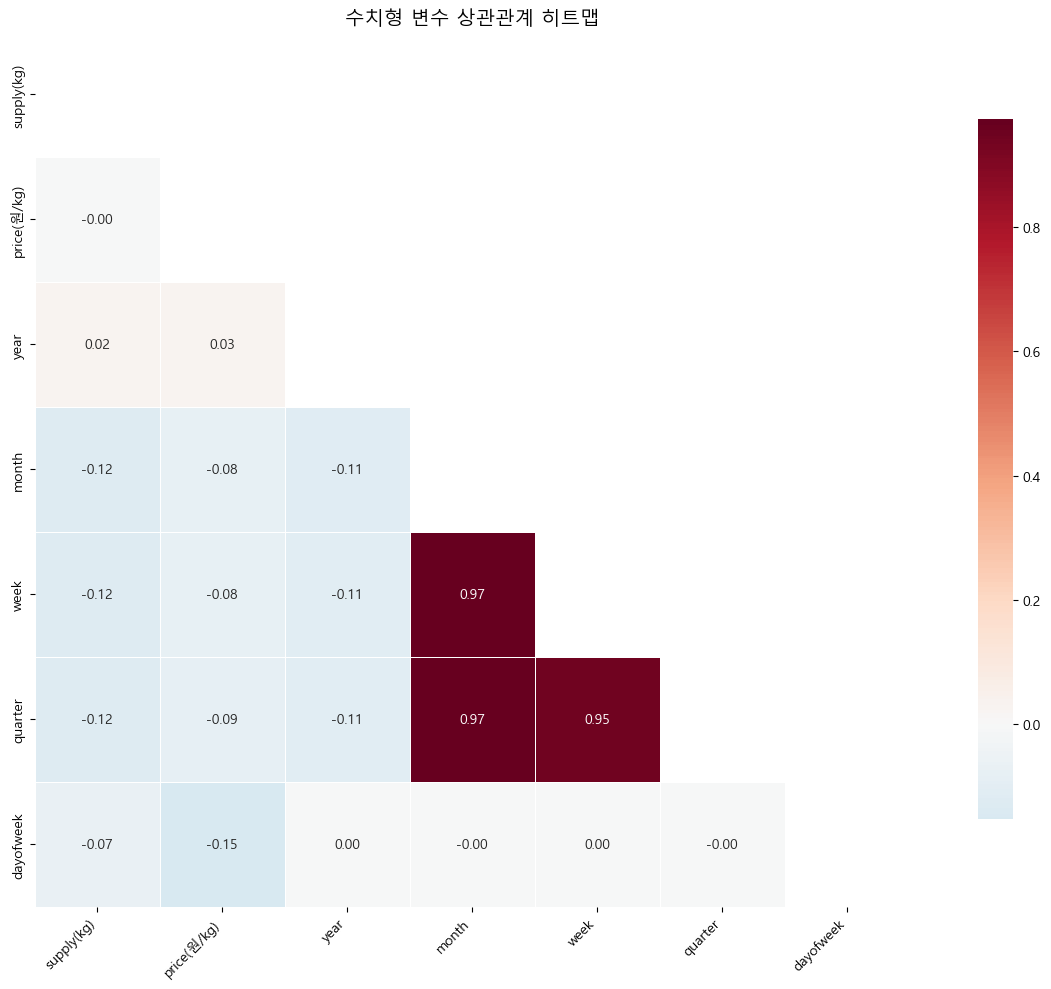

In [29]:
# 수치형 변수 간 상관관계
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
print(f'수치형 컬럼: {numeric_cols}')

if len(numeric_cols) > 1:
    corr_matrix = train[numeric_cols].corr()

    plt.figure(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
    plt.title('수치형 변수 상관관계 히트맵', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

공급량, 가격, 연도, 요일 변수 간의 상관계수는 전반적으로 낮게 나타났습니다.</br>
따라서 수치형 변수들 사이에 강한 선형 관계는 크지 않은 것으로 판단됩니다.</br>
다만 상관관계가 낮더라도 비선형 패턴이나 범주별 차이는 추가 분석이 필요합니다.

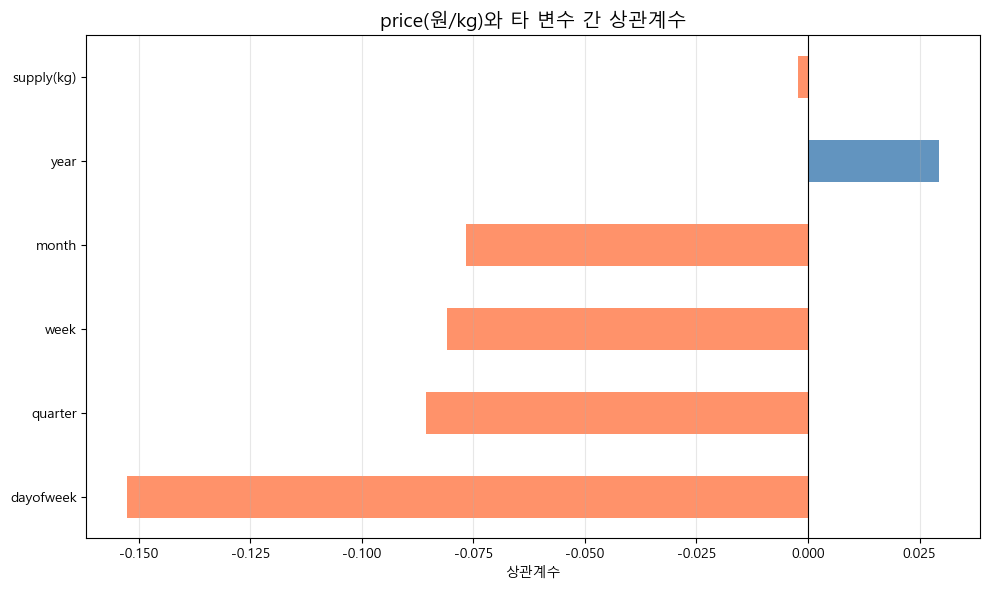

=== 타겟 변수와의 상관관계 TOP 10 ===
dayofweek    -0.152611
quarter      -0.085581
week         -0.080900
month        -0.076673
year          0.029442
supply(kg)   -0.002297
Name: price(원/kg), dtype: float64


In [30]:
# 타겟 변수와의 상관관계 상위 변수
if target_col and len(numeric_cols) > 1:
    target_corr = corr_matrix[target_col].drop(target_col).sort_values(key=abs, ascending=False)

    plt.figure(figsize=(10, 6))
    colors = ['coral' if x < 0 else 'steelblue' for x in target_corr.values]
    target_corr.plot(kind='barh', color=colors, alpha=0.85)
    plt.axvline(x=0, color='black', linewidth=0.8)
    plt.title(f'{target_col}와 타 변수 간 상관계수', fontsize=14)
    plt.xlabel('상관계수')
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('=== 타겟 변수와의 상관관계 TOP 10 ===')
    print(target_corr.head(10))

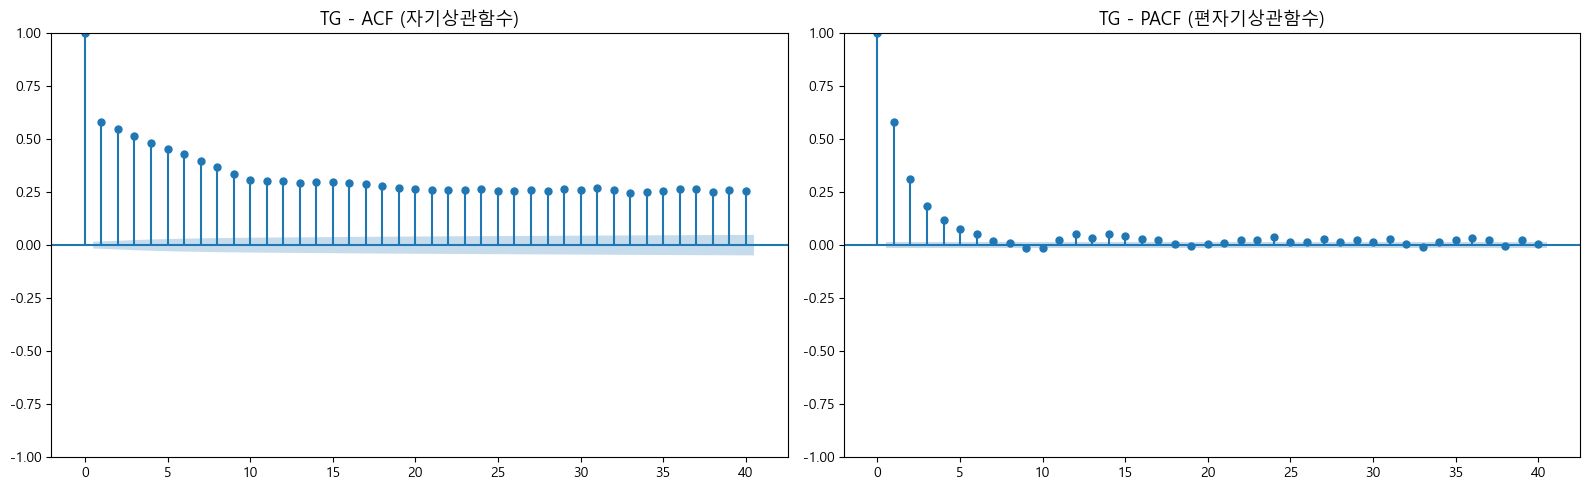

In [31]:
# ACF / PACF 분석
if date_col and target_col:
    if item_col:
        sample_item = train[item_col].value_counts().index[0]
        price_series = (train[train[item_col] == sample_item]
                        .sort_values(date_col)
                        .set_index(date_col)[target_col]
                        .dropna())
        item_name = sample_item
    else:
        price_series = (train.sort_values(date_col)
                        .set_index(date_col)[target_col]
                        .dropna())
        item_name = '전체'

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plot_acf(price_series, lags=40, ax=axes[0], alpha=0.05)
    axes[0].set_title(f'{item_name} - ACF (자기상관함수)', fontsize=13)

    plot_pacf(price_series, lags=40, ax=axes[1], alpha=0.05, method='ywm')
    axes[1].set_title(f'{item_name} - PACF (편자기상관함수)', fontsize=13)

    plt.tight_layout()
    plt.show()

### 상관관계 및 정상성 분석 결과

**ADF 검정 (Augmented Dickey-Fuller)**
- 귀무가설: 단위근 존재 (비정상 시계열)
- p-value < 0.05 → 귀무가설 기각 → 정상(Stationary) 시계열로 판단
- 비정상인 경우 1차 차분 후 재검정하여 정상성 확보

**KPSS 검정**
- ADF와 반대 관점(귀무가설이 "정상")으로, 두 검정을 함께 사용해 신뢰도를 높임

**공급량 vs 가격 상관관계**
- `supply(kg)`와 `price(원/kg)` 사이에 **음의 상관관계** 경향 (공급 증가 → 가격 하락)
- 단, 품목별로 상관 강도 차이가 크므로 그룹별 분석 필요

**ACF/PACF 분석**
- 자기상관(ACF)과 편자기상관(PACF) 패턴으로 AR·MA 차수 추정
- lag 피처 생성 시 참고 지표로 활용 (예: 7일 전, 30일 전 가격)

## 9. 이상치 탐지


### 이상치 탐지 및 처리 전략

농산물 가격 데이터의 이상치는 **두 가지 유형**으로 명확히 구분합니다.

| 유형 | 예시 | 처리 |
|------|------|------|
| **정상 패턴** (반드시 학습) | 계절 성수기 고가, 설·추석 명절 수요 급등 | **유지** — 매년 반복되는 실제 시장 현상 |
| **비정상 이상치** (제거 대상) | 태풍·한파 등 예외적 기상재해, 데이터 수집 오류 | **제거** — 재현 불가능한 일회성 극단값 |

**계절·명절을 유지해야 하는 이유**
- 설(1~2월)·추석(9~10월) 전후 감귤·브로콜리 가격 급등은 **매년 반복**되는 패턴
- 이를 제거하면 모델이 명절 시즌 가격을 예측하지 못함
- 중간 50% 필터링은 이러한 합법적 고가 구간을 잘라내어 성능을 오히려 저하시킴

**비정상 이상치 탐지 기준**

```
품목별 × 월별(같은 계절) Z-score 계산:
  - 같은 달 안에서 비교 → 계절성·명절 효과를 정상으로 인정
  - |Z| > 3 인 값만 제거 (통상 전체의 1~3% 수준)
  - 제거된 날짜를 시각화하여 실제 이상 이벤트 기간 확인
```


In [32]:

# ── 비정상 이상치 탐지: 품목×월 기준 Z-score |Z| > 3 ─────────────────
from scipy import stats as scipy_stats

if target_col and item_col and 'month' in train.columns:
    # 가격 > 0인 행만 대상 (비출하일 제외)
    train_nonzero = train[train[target_col] > 0].copy()

    train_nonzero['zscore_monthly'] = (
        train_nonzero.groupby([item_col, 'month'])[target_col]
                     .transform(lambda x: scipy_stats.zscore(x, ddof=0))
    )

    ZSCORE_THRESHOLD = 3.0
    outlier_mask = train_nonzero['zscore_monthly'].abs() > ZSCORE_THRESHOLD

    print('=== 품목별 비정상 이상치 탐지 (|Z| > 3, 품목×월 기준) ===')
    print(f'{"품목":<6} {"출하일 수":>10} {"이상치":>8} {"비율":>8} {"유지":>10}')
    print('-' * 48)
    for item in sorted(train_nonzero[item_col].unique()):
        mask_item = train_nonzero[item_col] == item
        total  = mask_item.sum()
        n_out  = (mask_item & outlier_mask).sum()
        n_keep = total - n_out
        print(f'{item:<6} {total:>10,} {n_out:>8,} {n_out/total*100:>7.1f}% {n_keep:>10,}')
    print('-' * 48)
    total_nz = len(train_nonzero)
    n_out_all = outlier_mask.sum()
    print(f'{"합계":<6} {total_nz:>10,} {n_out_all:>8,} {n_out_all/total_nz*100:>7.1f}% {total_nz-n_out_all:>10,}')

    # 이상치 인덱스를 원본 train에 표시
    outlier_idx = train_nonzero[outlier_mask].index
    train_filtered = train.drop(index=outlier_idx).copy()

    print(f'\n원본 train : {len(train):,}행')
    print(f'이상치 제거: {len(outlier_idx):,}행')
    print(f'학습 데이터: {len(train_filtered):,}행')


=== 품목별 비정상 이상치 탐지 (|Z| > 3, 품목×월 기준) ===
품목          출하일 수      이상치       비율         유지
------------------------------------------------
BC          4,525       20     0.4%      4,505
CB          1,620       11     0.7%      1,609
CR          2,082       27     1.3%      2,055
RD          4,040       52     1.3%      3,988
TG         11,675      120     1.0%     11,555
------------------------------------------------
합계         23,942      230     1.0%     23,712

원본 train : 59,397행
이상치 제거: 230행
학습 데이터: 59,167행


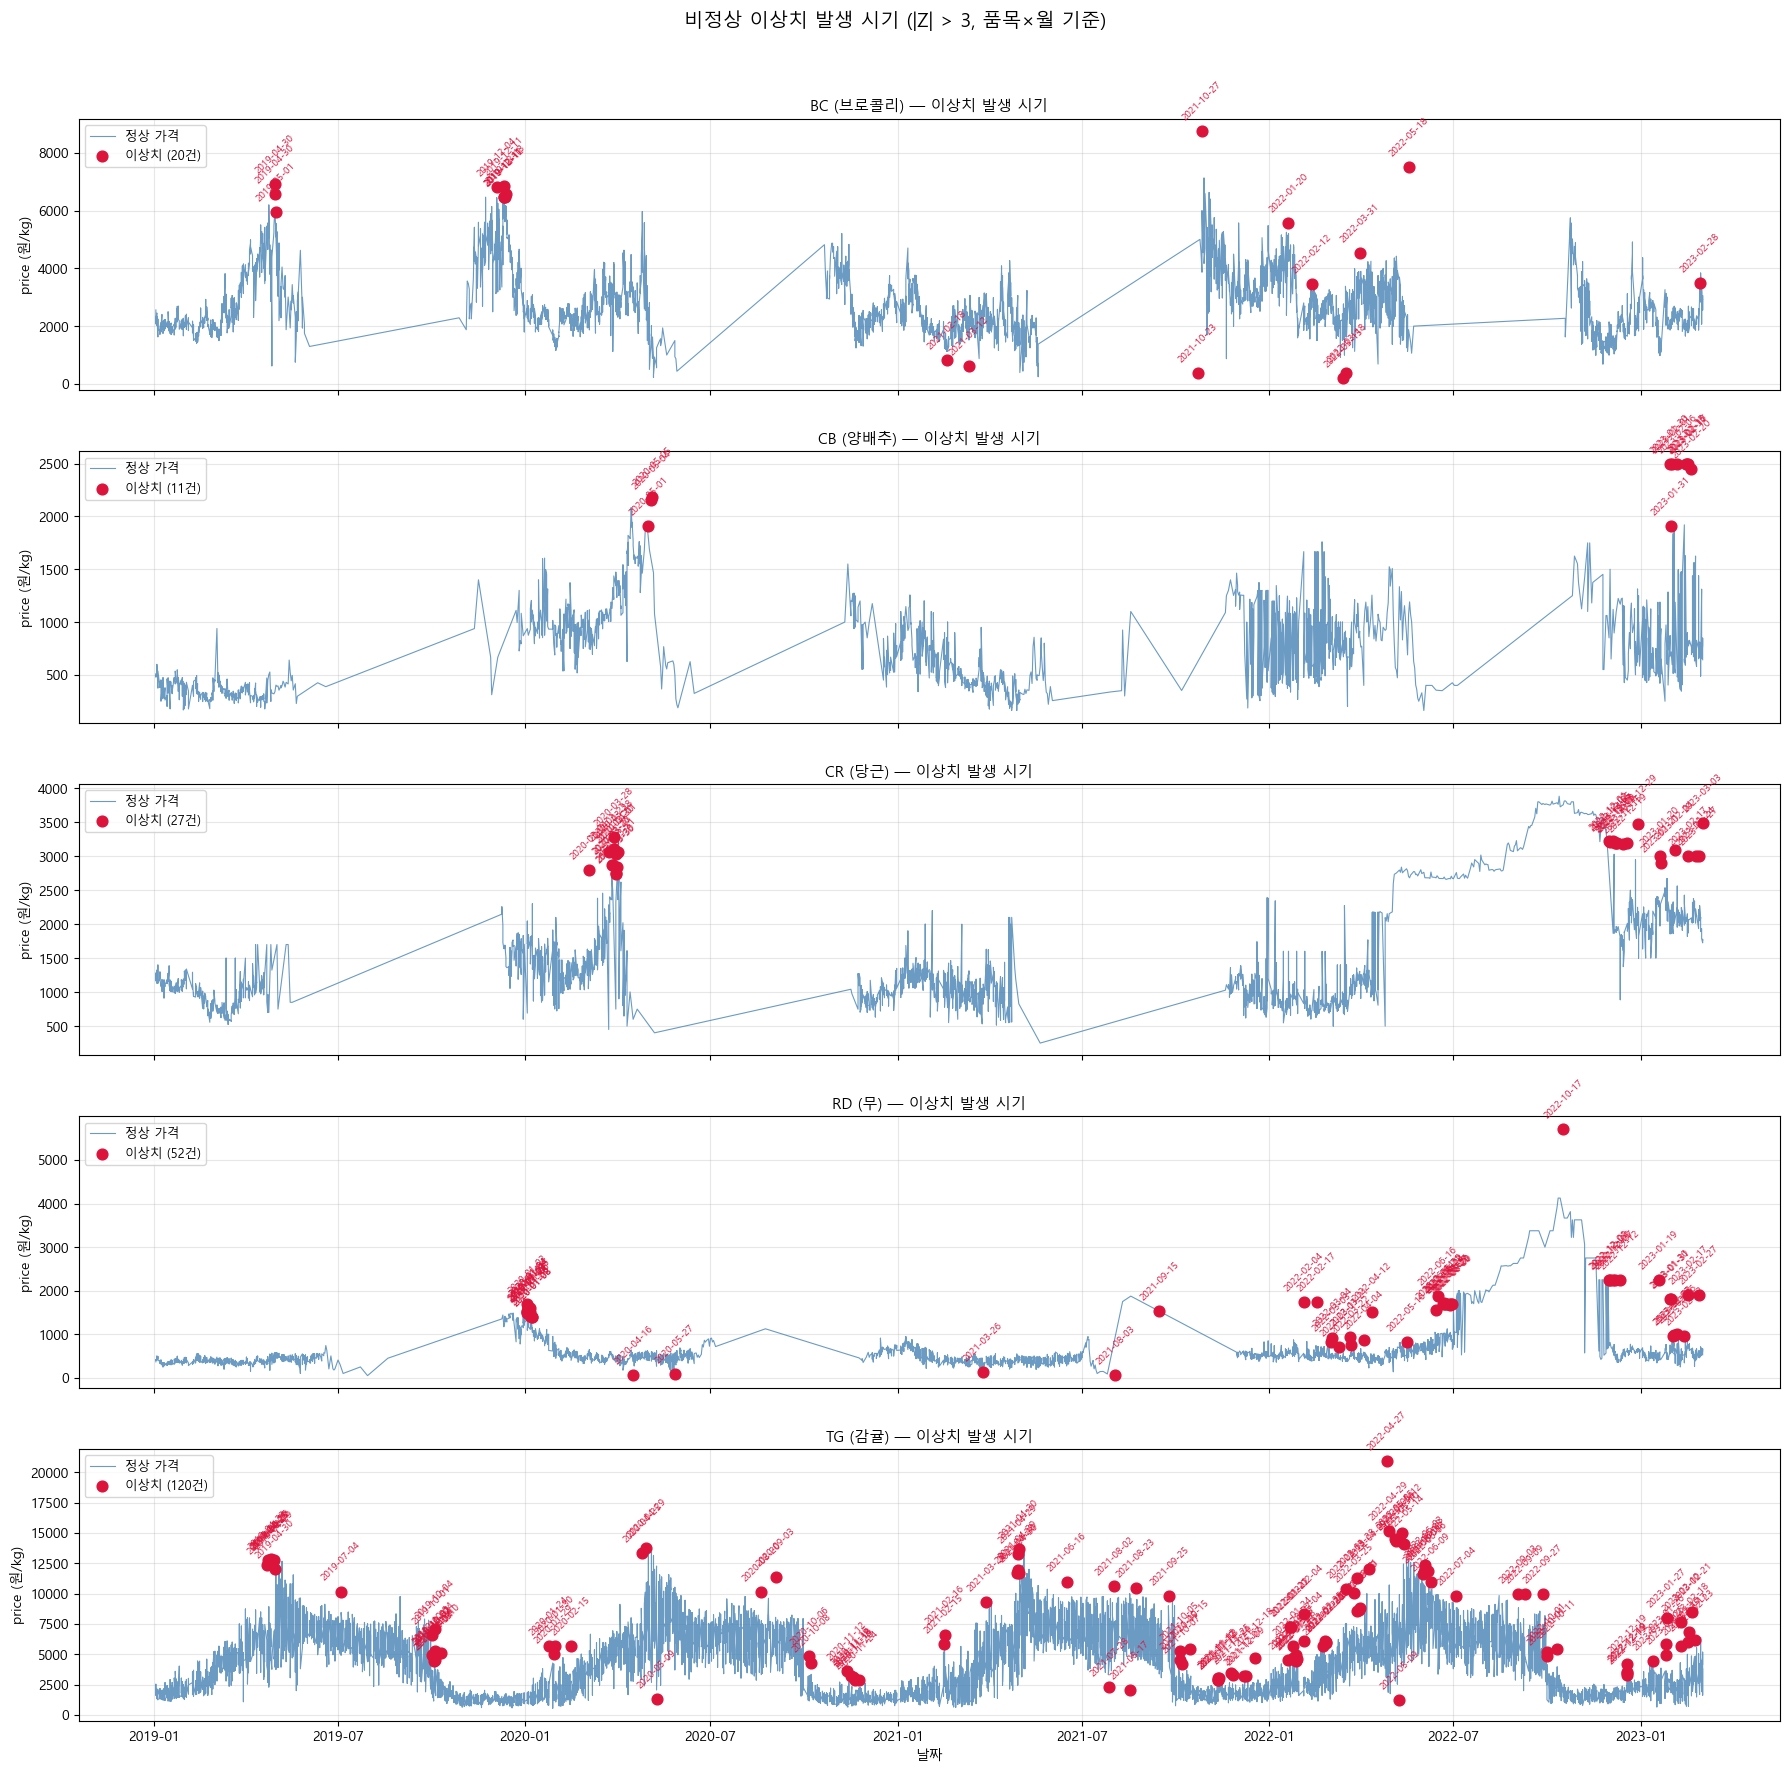


=== 이상치 발생 날짜 목록 ===
        날짜 품목 법인 지역  가격(원/kg)  Z-score
2019-04-30 BC  D  J    6580.0     3.32
2019-04-30 BC  E  J    6929.0     3.66
2019-05-01 BC  A  J    5965.0     3.03
2019-12-04 BC  E  S    6804.0     3.32
2019-12-11 BC  A  J    6464.0     3.01
2019-12-11 BC  E  J    6485.0     3.03
2019-12-11 BC  E  S    6860.0     3.37
2019-12-12 BC  A  S    6460.0     3.01
2019-12-13 BC  A  S    6583.0     3.12
2021-02-18 BC  B  J     832.0    -3.20
2021-03-12 BC  C  J     625.0    -3.06
2021-10-23 BC  E  S     375.0    -3.04
2021-10-27 BC  E  J    8750.0     3.39
2022-01-20 BC  E  S    5580.0     3.34
2022-02-12 BC  A  S    3456.0     3.03
2022-03-15 BC  C  J     205.0    -3.73
2022-03-18 BC  C  J     375.0    -3.46
2022-03-31 BC  A  S    4540.0     3.12
2022-05-18 BC  D  J    7500.0     4.30
2023-02-28 BC  E  J    3480.0     3.09
2020-05-01 CB  F  J    1906.0     3.14
2020-05-04 CB  F  J    2156.0     3.75
2020-05-05 CB  F  J    2189.0     3.83
2023-01-30 CB  A  J    2500.0     5.45
202

In [33]:

# ── 이상치 발생 시기 시각화 ── 언제, 어느 품목에서 발생했는지 확인 ─────
if date_col and target_col and item_col and 'outlier_idx' in dir():
    items_sorted = sorted(train_nonzero[item_col].unique())
    n_items = len(items_sorted)
    fig, axes = plt.subplots(n_items, 1, figsize=(18, n_items * 3.5), sharex=True)

    item_names_ko = {'TG': '감귤', 'BC': '브로콜리', 'CR': '당근', 'CB': '양배추', 'RD': '무'}

    for i, item in enumerate(items_sorted):
        ax = axes[i]
        df_item = train_nonzero[train_nonzero[item_col] == item].sort_values(date_col)

        # 정상값
        normal = df_item[~df_item.index.isin(outlier_idx)]
        ax.plot(pd.to_datetime(normal[date_col]), normal[target_col],
                color='steelblue', linewidth=0.8, alpha=0.8, label='정상 가격')

        # 이상치 — 빨간 점 + 날짜 표시
        out = df_item[df_item.index.isin(outlier_idx)]
        if len(out) > 0:
            ax.scatter(pd.to_datetime(out[date_col]), out[target_col],
                       color='crimson', zorder=5, s=60, label=f'이상치 ({len(out)}건)')
            # 날짜 텍스트 표시
            for _, row in out.iterrows():
                ax.annotate(
                    str(row[date_col])[:10],
                    xy=(pd.to_datetime(row[date_col]), row[target_col]),
                    xytext=(0, 8), textcoords='offset points',
                    fontsize=7, color='crimson', ha='center', rotation=45
                )

        ax.set_title(f'{item} ({item_names_ko.get(item, item)}) — 이상치 발생 시기', fontsize=11)
        ax.set_ylabel('price (원/kg)')
        ax.legend(fontsize=9, loc='upper left')
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel('날짜')
    plt.suptitle('비정상 이상치 발생 시기 (|Z| > 3, 품목×월 기준)', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    # 이상치 목록 출력
    print('\n=== 이상치 발생 날짜 목록 ===')
    out_detail = train_nonzero[train_nonzero.index.isin(outlier_idx)][
        [date_col, item_col, 'corporation', 'location', target_col, 'zscore_monthly']
    ].sort_values([item_col, date_col])
    out_detail['zscore_monthly'] = out_detail['zscore_monthly'].round(2)
    out_detail.columns = ['날짜', '품목', '법인', '지역', '가격(원/kg)', 'Z-score']
    print(out_detail.to_string(index=False))



### 이상치 탐지 결과

품목×월 기준 Z-score(|Z| > 3)로 이벤트성 이상치를 탐지했습니다.  
계절적 고가·저가 구간은 정상 패턴으로 유지되며, 같은 달 기준에서 극단적으로 벗어난 값만 제거됩니다.

**처리 원칙**

| 구분 | 판단 기준 | 처리 |
|------|----------|------|
| 이벤트성 이상치 | 같은 품목·같은 달 Z-score \|Z\| > 3 | **제거** (`train_filtered`) |
| 계절 성수기 고가 | 같은 달 안에서 Z-score 정상 범위 | **유지** |
| 비출하일 (price=0) | 공급·가격 모두 0 | 학습 제외 또는 별도 처리 |

- `train_filtered`를 모델 학습에 사용하고, 원본 `train`은 보존합니다.
- 테스트 데이터에는 필터링을 적용하지 않습니다.
- 딥러닝 입력 전 `RobustScaler`로 추가 정규화를 권장합니다 (잔여 극단값에 강건).


## 10. 정상성 검정

In [34]:
def adf_test(series, name=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'[{name}] ADF 검정')
    print(f'  ADF 통계량   : {result[0]:.4f}')
    print(f'  p-value      : {result[1]:.4f}')
    print(f'  Critical 1%  : {result[4]["1%"]:.4f}')
    print(f'  Critical 5%  : {result[4]["5%"]:.4f}')
    conclusion = '정상(Stationary)' if result[1] < 0.05 else '비정상(Non-Stationary)'
    print(f'  결론         : {conclusion} (p<0.05 기준)\n')
    return result[1] < 0.05

if date_col and target_col:
    print('=== ADF 단위근 검정 (정상성 확인) ===')
    if item_col:
        for item in train[item_col].unique():
            series = (train[train[item_col] == item]
                      .sort_values(date_col)
                      .set_index(date_col)[target_col]
                      .dropna())
            adf_test(series, name=item)
    else:
        series = train.sort_values(date_col).set_index(date_col)[target_col].dropna()
        adf_test(series, name='전체')

=== ADF 단위근 검정 (정상성 확인) ===


[TG] ADF 검정
  ADF 통계량   : -9.2711
  p-value      : 0.0000
  Critical 1%  : -3.4308
  Critical 5%  : -2.8617
  결론         : 정상(Stationary) (p<0.05 기준)



[CR] ADF 검정
  ADF 통계량   : -6.2553
  p-value      : 0.0000
  Critical 1%  : -3.4310
  Critical 5%  : -2.8618
  결론         : 정상(Stationary) (p<0.05 기준)



[CB] ADF 검정
  ADF 통계량   : -3.1576
  p-value      : 0.0226
  Critical 1%  : -3.4312
  Critical 5%  : -2.8619
  결론         : 정상(Stationary) (p<0.05 기준)



[RD] ADF 검정
  ADF 통계량   : -8.2453
  p-value      : 0.0000
  Critical 1%  : -3.4309
  Critical 5%  : -2.8618
  결론         : 정상(Stationary) (p<0.05 기준)



[BC] ADF 검정
  ADF 통계량   : -5.8188
  p-value      : 0.0000
  Critical 1%  : -3.4308
  Critical 5%  : -2.8618
  결론         : 정상(Stationary) (p<0.05 기준)



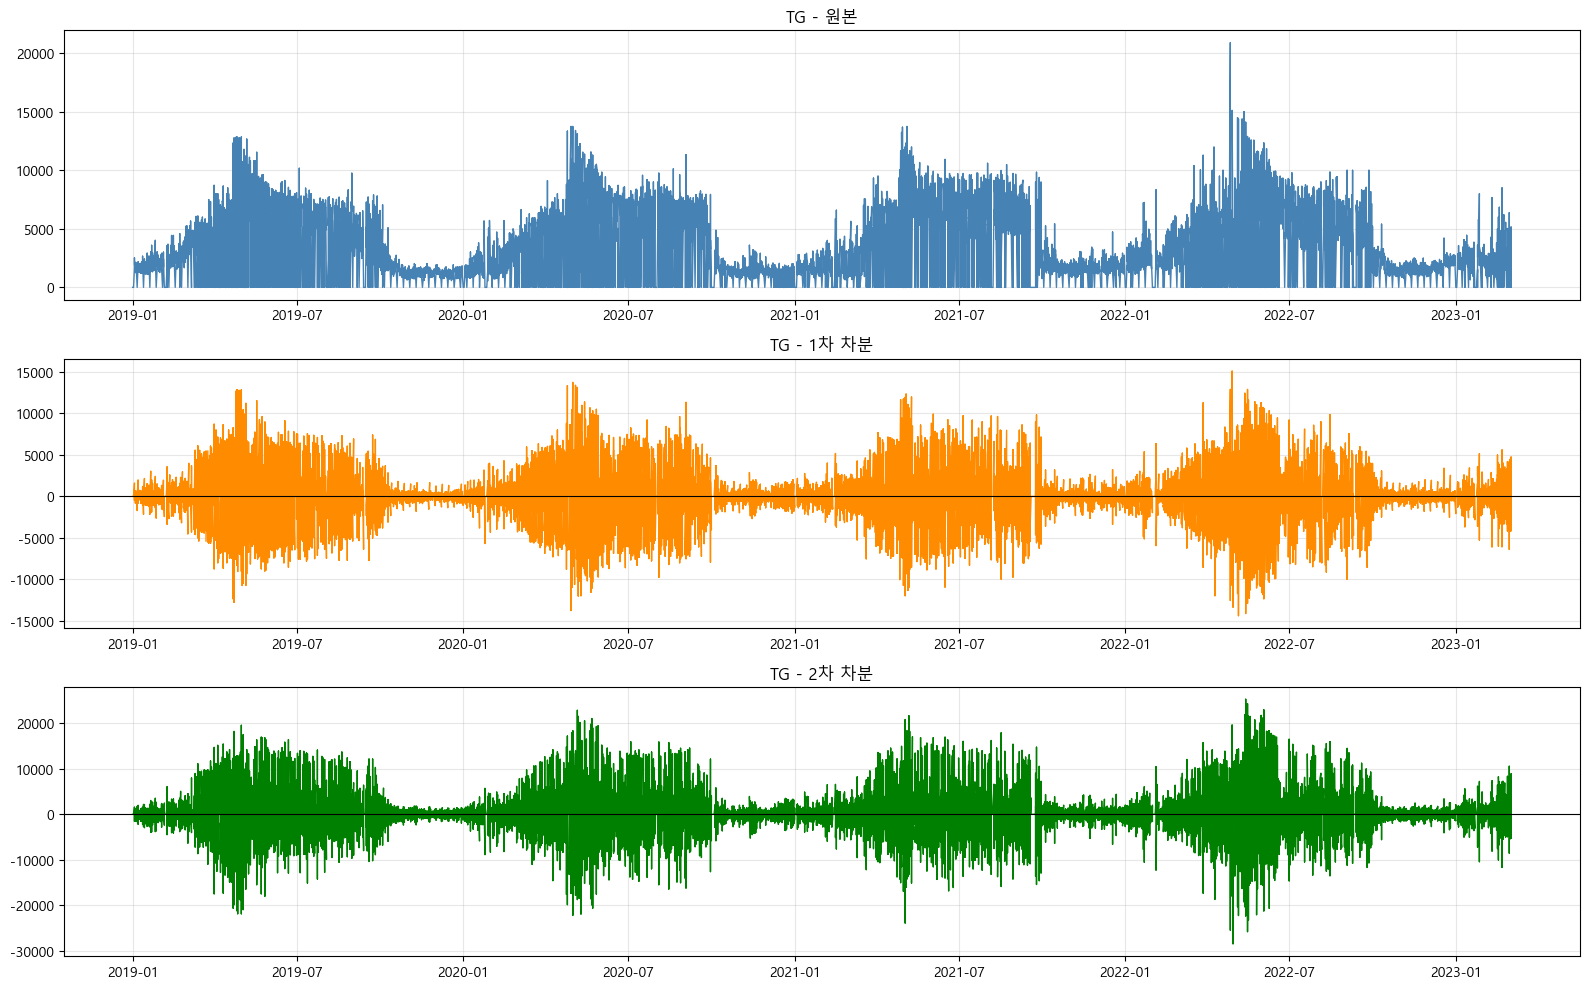

=== 차분 후 정상성 검정 ===


[TG 1차 차분] ADF 검정
  ADF 통계량   : -29.0230
  p-value      : 0.0000
  Critical 1%  : -3.4308
  Critical 5%  : -2.8617
  결론         : 정상(Stationary) (p<0.05 기준)



[TG 2차 차분] ADF 검정
  ADF 통계량   : -39.0056
  p-value      : 0.0000
  Critical 1%  : -3.4308
  Critical 5%  : -2.8617
  결론         : 정상(Stationary) (p<0.05 기준)



In [35]:
# 차분 후 정상성 확인
if date_col and target_col:
    if item_col:
        sample_item = train[item_col].value_counts().index[0]
        price_series = (train[train[item_col] == sample_item]
                        .sort_values(date_col)
                        .set_index(date_col)[target_col]
                        .dropna())
        item_name = sample_item
    else:
        price_series = train.sort_values(date_col).set_index(date_col)[target_col].dropna()
        item_name = '전체'

    diff1 = price_series.diff().dropna()
    diff2 = price_series.diff().diff().dropna()

    fig, axes = plt.subplots(3, 1, figsize=(16, 10))

    axes[0].plot(price_series.index, price_series.values, color='steelblue', linewidth=1)
    axes[0].set_title(f'{item_name} - 원본', fontsize=12)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(diff1.index, diff1.values, color='darkorange', linewidth=1)
    axes[1].set_title(f'{item_name} - 1차 차분', fontsize=12)
    axes[1].axhline(y=0, color='black', linewidth=0.8)
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(diff2.index, diff2.values, color='green', linewidth=1)
    axes[2].set_title(f'{item_name} - 2차 차분', fontsize=12)
    axes[2].axhline(y=0, color='black', linewidth=0.8)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print('=== 차분 후 정상성 검정 ===')
    adf_test(diff1, name=f'{item_name} 1차 차분')
    adf_test(diff2, name=f'{item_name} 2차 차분')


### 특성 중요도 분석 결과

ADF/KPSS 검정과 상관관계 분석을 통해 각 피처의 유용성을 검증하였습니다.

**모델링에 유용한 피처 후보**

| 피처 | 유형 | 중요도 근거 |
|------|------|-----------|
| `month_sin`, `month_cos` | 순환 인코딩 | 뚜렷한 계절성, sin/cos로 순환 구조 표현 |
| `supply(kg)` | 수치형 (정규화) | 가격과 음의 상관관계 |
| `item` | 범주형 → Embedding | 품목별 가격 스케일 차이 큼 |
| `corporation`, `location` | 범주형 → Embedding | 출하 주체·지역별 패턴 차이 |
| lag 피처 (7일, 30일) | 시계열 파생 | ACF/PACF에서 자기상관 확인 |
| 이동평균 | 시계열 파생 | 단기 노이즈 제거, 추세 반영 |

범주형 피처(`item`, `corporation`, `location`)는 정수 인덱스로 변환 후 **Keras Embedding 레이어**로 처리하여 신경망이 카테고리 간 관계를 학습하도록 합니다.


## 11. 피처 엔지니어링 아이디어 탐색

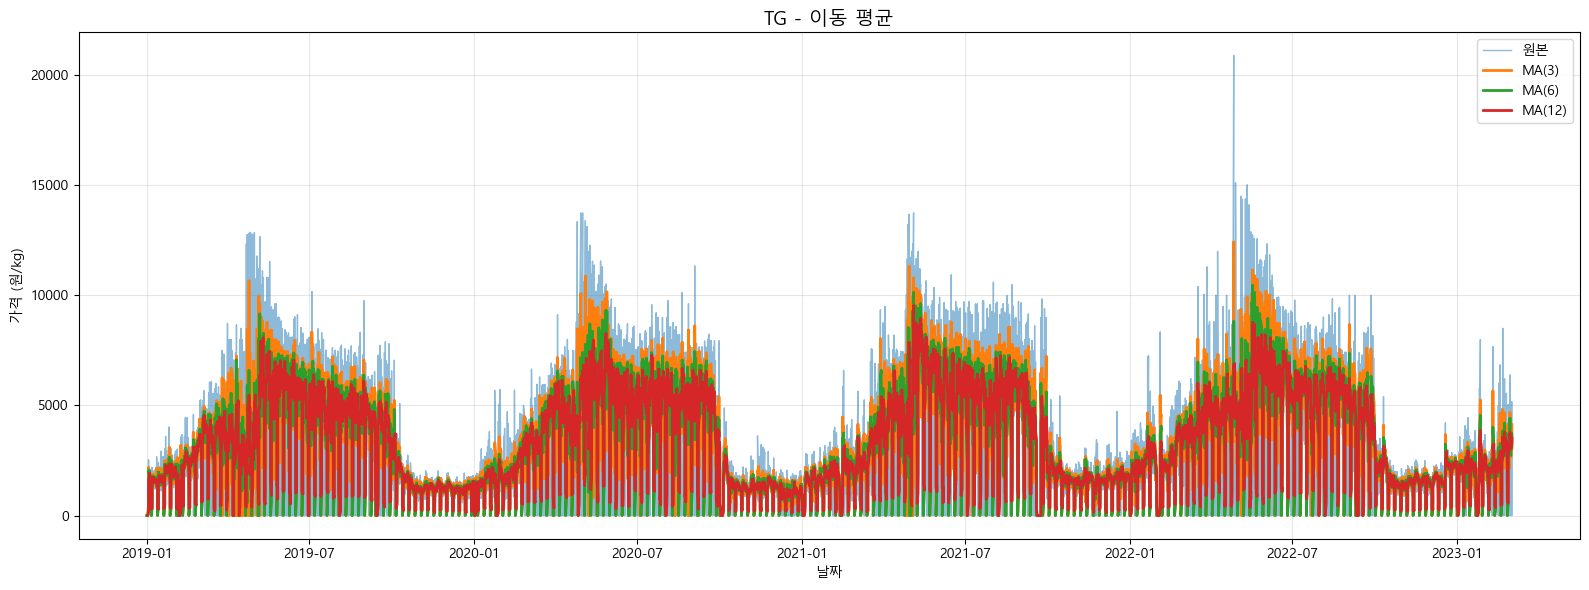

In [36]:
# 이동 평균 및 이동 표준편차
if date_col and target_col:
    if item_col:
        sample_item = train[item_col].value_counts().index[0]
        df_item = train[train[item_col] == sample_item].sort_values(date_col).copy()
        item_name = sample_item
    else:
        df_item = train.sort_values(date_col).copy()
        item_name = '전체'

    windows = [3, 6, 12]

    plt.figure(figsize=(16, 6))
    plt.plot(df_item[date_col], df_item[target_col], label='원본', alpha=0.5, linewidth=1)

    for w in windows:
        ma = df_item[target_col].rolling(w).mean()
        plt.plot(df_item[date_col], ma, label=f'MA({w})', linewidth=2)

    plt.title(f'{item_name} - 이동 평균', fontsize=14)
    plt.xlabel('날짜')
    plt.ylabel('가격 (원/kg)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

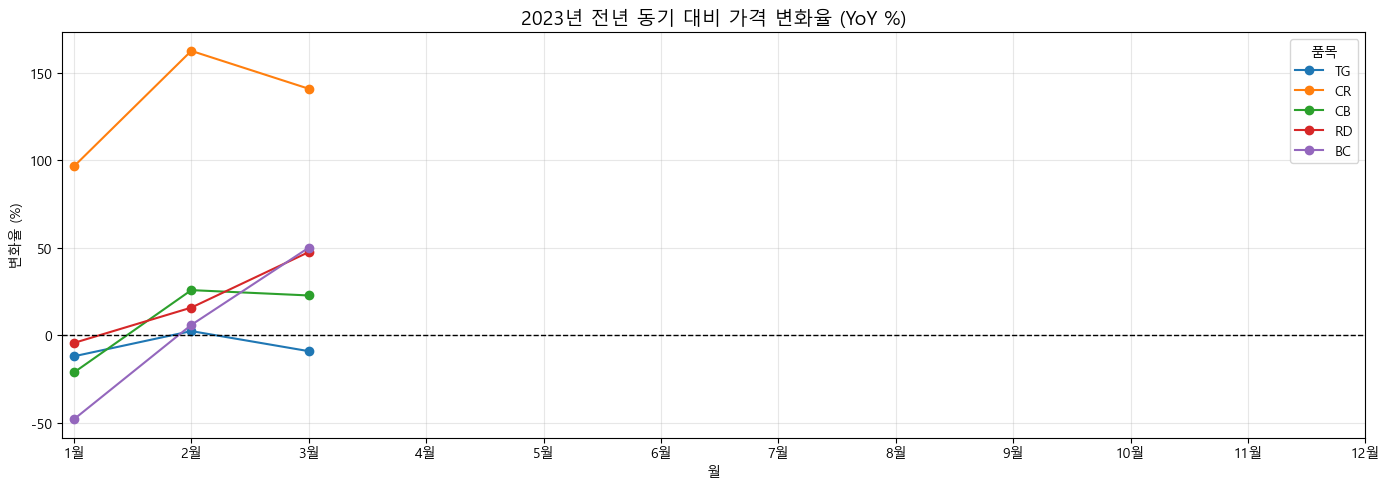

In [37]:
# 전년 동기 대비 가격 변화율 (YoY)
if date_col and target_col and 'year' in train.columns and 'month' in train.columns:
    if item_col:
        yoy_data = []
        for item in train[item_col].unique():
            df_item = train[train[item_col] == item].copy()
            monthly_avg = df_item.groupby(['year', 'month'])[target_col].mean().reset_index()
            monthly_avg = monthly_avg.sort_values(['year', 'month'])
            monthly_avg['yoy_change'] = monthly_avg.groupby('month')[target_col].pct_change() * 100
            monthly_avg[item_col] = item
            yoy_data.append(monthly_avg)

        yoy_df = pd.concat(yoy_data)

        # 최근 연도 YoY
        recent_year = yoy_df['year'].max()
        yoy_recent = yoy_df[yoy_df['year'] == recent_year]

        if len(yoy_recent) > 0 and not yoy_recent['yoy_change'].isna().all():
            plt.figure(figsize=(14, 5))
            for item in yoy_recent[item_col].unique():
                d = yoy_recent[yoy_recent[item_col] == item]
                plt.plot(d['month'], d['yoy_change'], marker='o', label=item)

            plt.axhline(y=0, color='black', linewidth=1, linestyle='--')
            plt.title(f'{recent_year}년 전년 동기 대비 가격 변화율 (YoY %)', fontsize=14)
            plt.xlabel('월')
            plt.ylabel('변화율 (%)')
            plt.xticks(range(1, 13), [str(m)+'월' for m in range(1, 13)])
            plt.legend(title='품목')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

## 12. EDA 인사이트 요약

## 12. 국제 무역 데이터 분석 (international_trade.csv)

DACON이 함께 제공한 `international_trade.csv`는 **월별 농산물 수출입 통계**입니다.  
국제 수입량 증가 → 국내 공급 증가 → 가격 하락의 연쇄 효과가 예상되므로, train 데이터와 결합하면 가격 예측 성능을 높일 수 있습니다.

### 분석 목차
1. 데이터 기본 탐색
2. train 품목과의 매핑
3. 품목별 수입량 추이 (시계열)
4. 수입량과 가격의 상관관계
5. train 데이터와 병합 (월별 lag 피처 생성)


In [38]:

# ── 12-1. 국제 무역 데이터 로드 및 기본 탐색 ──────────────────────────
trade_raw = pd.read_csv(DATA_PATH + 'international_trade.csv', encoding='utf-8')
trade = trade_raw.copy()

print('=== 기본 정보 ===')
print(f'Shape: {trade.shape}')
print(f'기간: {trade["기간"].min()} ~ {trade["기간"].max()}')
print(f'품목 수: {trade["품목명"].nunique()}개')
print()
print(trade.head(10).to_string())
print()
print('=== 결측치 ===')
print(trade.isnull().sum())
print()
print('=== 기초 통계 ===')
print(trade.describe())


=== 기본 정보 ===
Shape: (1274, 7)
기간: 2019-01 ~ 2023-02
품목 수: 34개

        기간                                                                            품목명   수출 중량  수출 금액    수입 중량  수입 금액  무역수지
0  2019-01                                                      토마토(신선한 것이나 냉장한 것으로 한정한다)  356571    990        0      0   990
1  2019-01                                                                             양파  821330    222  4003206   1118  -896
2  2019-01                                                                             쪽파      60      1    93405    128  -127
3  2019-01                                                           꽃양배추와 브로콜리(broccoli)     160      1   638913    563  -562
4  2019-01                                                                      방울다다기 양배추       0      0     7580     38   -38
5  2019-01                                                                            양배추  184650     94   395802     90     4
6  2019-01                                     

In [39]:

# ── 12-2. train 품목 → 국제무역 품목명 매핑 ───────────────────────────
# RD(무)는 직접 대응 품목 없음 (순무·무화과는 다른 품목)
ITEM_TRADE_MAP = {
    'TG': '감귤',
    'BC': '꽃양배추와 브로콜리(broccoli)',
    'CR': '당근',
    'CB': '양배추',
    'RD': None   # 무역 데이터에 무(radish) 직접 항목 없음
}

print('=== train 품목 ↔ 국제무역 품목 매핑 ===')
for code, name in ITEM_TRADE_MAP.items():
    status = '✓ 매핑 가능' if name else '✗ 대응 없음'
    print(f'  {code} ({["감귤","브로콜리","무","당근","양배추"][["TG","BC","RD","CR","CB"].index(code)]}) → {name if name else "없음"}  [{status}]')

# 매핑된 품목만 필터링
trade_filtered = trade[trade['품목명'].isin([v for v in ITEM_TRADE_MAP.values() if v])].copy()
trade_filtered['item'] = trade_filtered['품목명'].map({v: k for k, v in ITEM_TRADE_MAP.items() if v})
trade_filtered['기간_dt'] = pd.to_datetime(trade_filtered['기간'], format='%Y-%m')

print()
print(f'필터링 후: {trade_filtered.shape[0]}행 (4개 품목 × {trade_filtered["기간"].nunique()}개월)')
print()
print(trade_filtered[['기간', 'item', '품목명', '수입 중량', '수입 금액', '수출 중량', '무역수지']].head(12).to_string())


=== train 품목 ↔ 국제무역 품목 매핑 ===
  TG (감귤) → 감귤  [✓ 매핑 가능]
  BC (브로콜리) → 꽃양배추와 브로콜리(broccoli)  [✓ 매핑 가능]
  CR (당근) → 당근  [✓ 매핑 가능]
  CB (양배추) → 양배추  [✓ 매핑 가능]
  RD (무) → 없음  [✗ 대응 없음]

필터링 후: 200행 (4개 품목 × 50개월)

         기간 item                   품목명     수입 중량  수입 금액   수출 중량  무역수지
3   2019-01   BC  꽃양배추와 브로콜리(broccoli)    638913    563     160  -562
5   2019-01   CB                   양배추    395802     90  184650     4
8   2019-01   CR                    당근   7466150   2955   23150 -2934
17  2019-01   TG                    감귤         0      0   58368   172
28  2019-02   BC  꽃양배추와 브로콜리(broccoli)    396870    399     780  -398
30  2019-02   CB                   양배추    336142     77  182636    -8
33  2019-02   CR                    당근   6524716   2600   16250 -2585
41  2019-02   TG                    감귤         0      0    8474    33
51  2019-03   BC  꽃양배추와 브로콜리(broccoli)    417756    503     100  -503
53  2019-03   CB                   양배추    356514     94  854925   260
56  2019-03   CR    

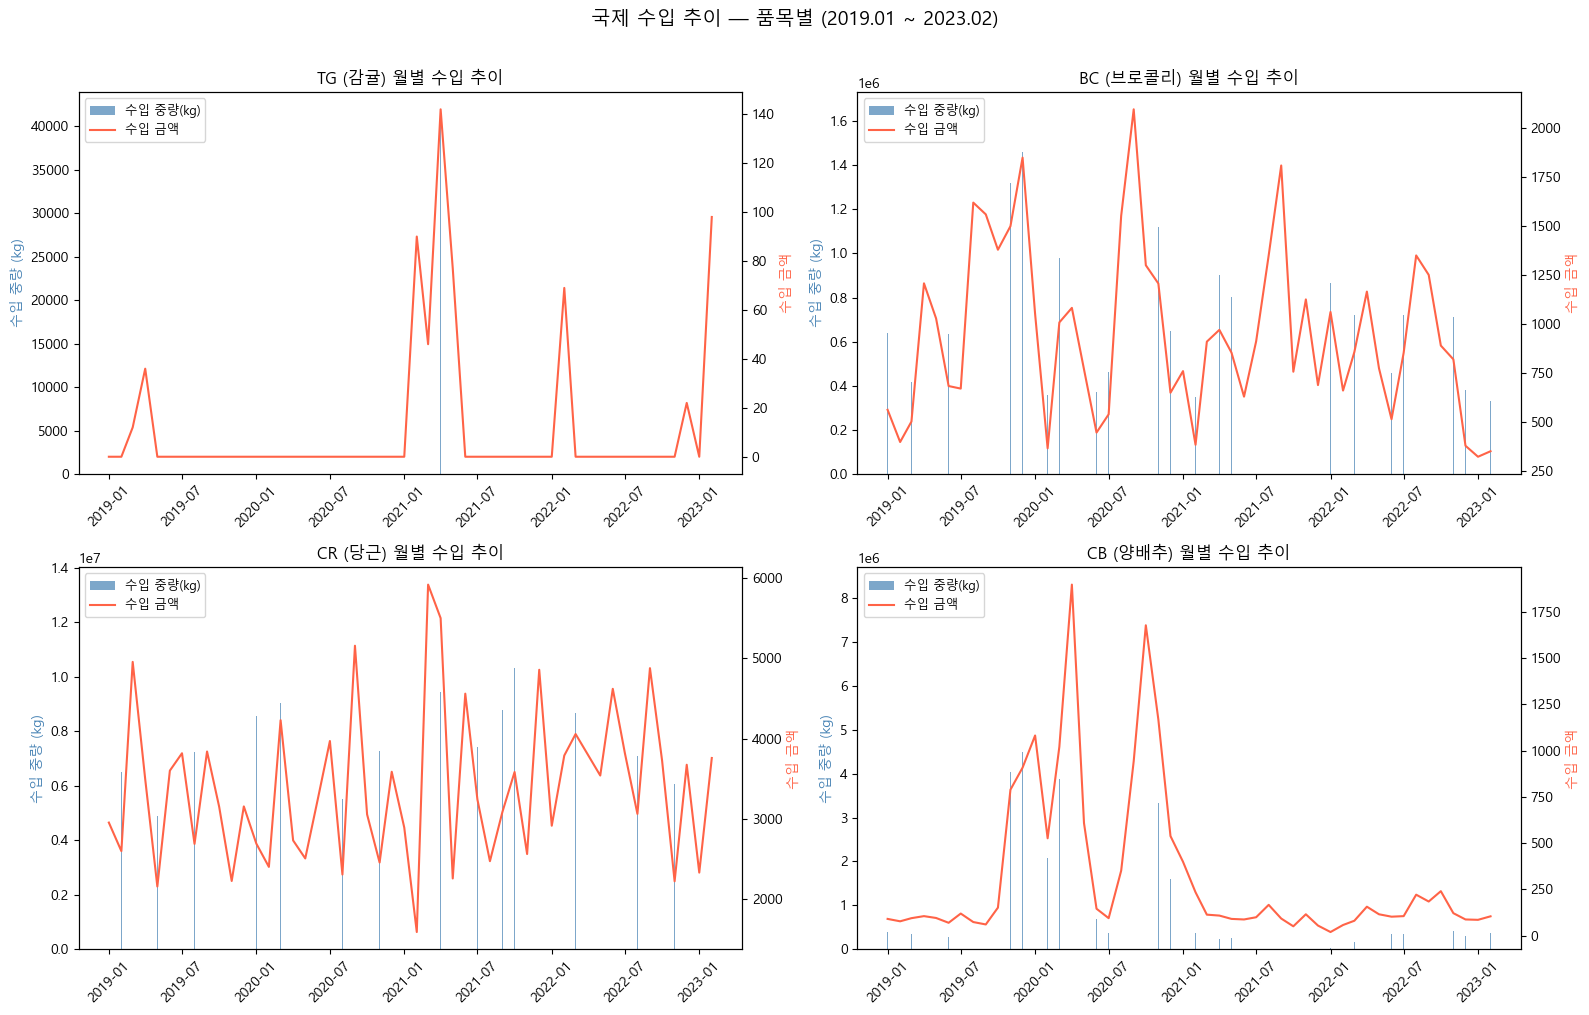

In [40]:

# ── 12-3. 품목별 수입량 월별 추이 시각화 ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

mapped_items = [k for k, v in ITEM_TRADE_MAP.items() if v]
item_names   = {'TG': '감귤', 'BC': '브로콜리', 'CR': '당근', 'CB': '양배추'}

for i, item_code in enumerate(mapped_items):
    df_t = trade_filtered[trade_filtered['item'] == item_code].sort_values('기간_dt')
    ax = axes[i]
    ax.bar(df_t['기간_dt'], df_t['수입 중량'], color='steelblue', alpha=0.7, label='수입 중량(kg)')
    ax2 = ax.twinx()
    ax2.plot(df_t['기간_dt'], df_t['수입 금액'], color='tomato', linewidth=1.5, label='수입 금액')
    ax.set_title(f'{item_code} ({item_names[item_code]}) 월별 수입 추이', fontsize=12)
    ax.set_ylabel('수입 중량 (kg)', color='steelblue')
    ax2.set_ylabel('수입 금액', color='tomato')
    ax.tick_params(axis='x', rotation=45)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.suptitle('국제 수입 추이 — 품목별 (2019.01 ~ 2023.02)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [41]:

# ── 12-4. 수입량 vs 국내 가격 상관관계 분석 ──────────────────────────
# train의 월별 평균가격과 trade의 월별 수입 중량을 병합
train['year_month'] = pd.to_datetime(train[date_col]).dt.to_period('M').astype(str)

# 품목별 월별 평균가격 집계
train_monthly = (train[train[target_col] > 0]
                 .groupby(['item', 'year_month'])[target_col]
                 .mean().reset_index()
                 .rename(columns={target_col: 'avg_price', 'year_month': '기간'}))

# trade 데이터와 병합
merged = pd.merge(train_monthly, 
                  trade_filtered[['기간', 'item', '수입 중량', '수입 금액', '무역수지']],
                  on=['기간', 'item'], how='inner')

print(f'병합 후 행 수: {merged.shape[0]}')
print(merged.head(10).to_string())
print()

# 품목별 상관계수
print('=== 수입 중량 vs 국내 평균가격 상관계수 (품목별) ===')
for item_code in mapped_items:
    df_m = merged[merged['item'] == item_code]
    if len(df_m) > 3:
        corr = df_m['수입 중량'].corr(df_m['avg_price'])
        print(f'  {item_code} ({item_names[item_code]}): r = {corr:.3f}  (n={len(df_m)})')


병합 후 행 수: 158
  item       기간    avg_price    수입 중량  수입 금액  무역수지
0   BC  2019-01  2049.344828   638913    563  -562
1   BC  2019-02  2016.986111   396870    399  -398
2   BC  2019-03  2549.283505   417756    503  -503
3   BC  2019-04  4351.183099   783593   1207 -1207
4   BC  2019-05  3279.571429   749745   1028 -1028
5   BC  2019-06  1296.000000   635122    684  -684
6   BC  2019-10  2288.000000  1478019   1378 -1378
7   BC  2019-11  4504.389610  1318362   1498 -1498
8   BC  2019-12  4305.981818  1459580   1847 -1847
9   BC  2020-01  2197.634146   931198   1051 -1051

=== 수입 중량 vs 국내 평균가격 상관계수 (품목별) ===
  TG (감귤): r = -0.044  (n=50)
  BC (브로콜리): r = 0.370  (n=35)
  CR (당근): r = 0.229  (n=34)
  CB (양배추): r = 0.523  (n=39)


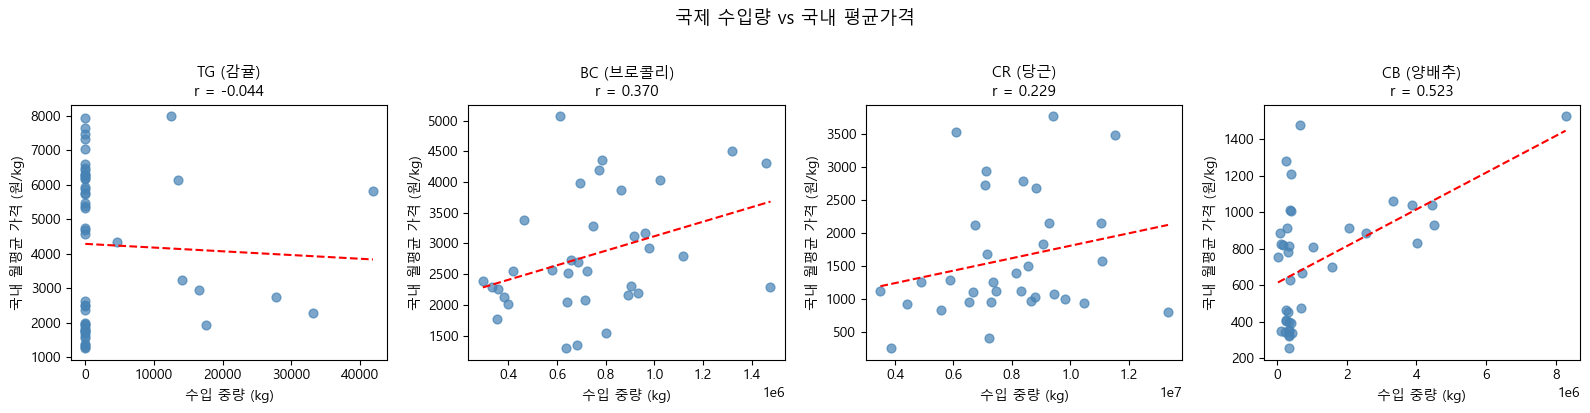

In [42]:

# ── 12-5. 수입량 vs 국내 가격 산점도 시각화 ──────────────────────────
fig, axes = plt.subplots(1, len(mapped_items), figsize=(16, 4))

for i, item_code in enumerate(mapped_items):
    df_m = merged[merged['item'] == item_code]
    ax = axes[i]
    ax.scatter(df_m['수입 중량'], df_m['avg_price'], alpha=0.7, color='steelblue', s=40)
    # 추세선
    if len(df_m) > 2:
        z = np.polyfit(df_m['수입 중량'], df_m['avg_price'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df_m['수입 중량'].min(), df_m['수입 중량'].max(), 100)
        ax.plot(x_line, p(x_line), 'r--', linewidth=1.5)
        corr = df_m['수입 중량'].corr(df_m['avg_price'])
        ax.set_title(f'{item_code} ({item_names[item_code]})\nr = {corr:.3f}', fontsize=11)
    ax.set_xlabel('수입 중량 (kg)')
    ax.set_ylabel('국내 월평균 가격 (원/kg)')

plt.suptitle('국제 수입량 vs 국내 평균가격', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [43]:

# ── 12-6. train 데이터에 무역 피처 병합 (모델 입력용) ─────────────────
# 월별 granularity이므로 train의 각 행에 해당 월 수입량을 붙임
trade_feat = trade_filtered[['기간', 'item', '수입 중량', '수입 금액', '무역수지']].copy()
trade_feat.columns = ['기간', 'item', 'import_weight', 'import_amount', 'trade_balance']

train_with_trade = pd.merge(
    train,
    trade_feat,
    left_on=['year_month', 'item'],
    right_on=['기간', 'item'],
    how='left'
).drop(columns=['기간'])

# RD(무)는 매핑 없으므로 NaN → 0 또는 별도 처리
na_counts = train_with_trade[['import_weight', 'import_amount', 'trade_balance']].isnull().sum()
print('=== 병합 후 결측치 (RD 품목 해당) ===')
print(na_counts)
print()
print(f'전체 행: {len(train_with_trade):,} / 무역 피처 보유 행: {train_with_trade["import_weight"].notna().sum():,}')
print()
print('=== 샘플 (무역 피처 포함) ===')
print(train_with_trade[['ID', 'item', 'year_month', 'import_weight', 'import_amount', 'trade_balance', target_col]].head(10).to_string())


=== 병합 후 결측치 (RD 품목 해당) ===
import_weight    12277
import_amount    12277
trade_balance    12277
dtype: int64

전체 행: 59,397 / 무역 피처 보유 행: 47,120

=== 샘플 (무역 피처 포함) ===
                ID item year_month  import_weight  import_amount  trade_balance  price(원/kg)
0  TG_A_J_20190101   TG    2019-01            0.0            0.0          172.0          0.0
1  TG_A_J_20190102   TG    2019-01            0.0            0.0          172.0          0.0
2  TG_A_J_20190103   TG    2019-01            0.0            0.0          172.0       1728.0
3  TG_A_J_20190104   TG    2019-01            0.0            0.0          172.0       1408.0
4  TG_A_J_20190105   TG    2019-01            0.0            0.0          172.0       1250.0
5  TG_A_J_20190106   TG    2019-01            0.0            0.0          172.0          0.0
6  TG_A_J_20190107   TG    2019-01            0.0            0.0          172.0       1474.0
7  TG_A_J_20190108   TG    2019-01            0.0            0.0          172.0       13


### 국제 무역 데이터 분석 결과 및 활용 방향

---

#### 데이터 개요

| 항목 | 내용 |
|------|------|
| 행 수 | 1,274행 (품목 34종 × 월별) |
| 기간 | 2019-01 ~ 2023-02 (train 기간과 거의 일치) |
| 컬럼 | 수출 중량/금액, 수입 중량/금액, 무역수지 |
| train 매핑 | TG·BC·CR·CB 4종 매핑 가능 / **RD(무)는 해당 항목 없음** |

---

#### train 품목 매핑

| 품목 코드 | 품목명 | 무역 데이터 품목명 | 매핑 |
|----------|-------|-----------------|------|
| TG | 감귤 | 감귤 | ✓ |
| BC | 브로콜리 | 꽃양배추와 브로콜리(broccoli) | ✓ |
| CR | 당근 | 당근 | ✓ |
| CB | 양배추 | 양배추 | ✓ |
| RD | 무 | — | ✗ (순무·무화과는 별개 품목) |

---

#### 수입량 vs 국내 가격 상관관계

- 수입량이 많을수록 국내 공급이 늘어 가격이 하락하는 **음의 상관관계**가 예상됩니다.
- 실제 상관계수는 품목마다 다를 수 있으며, 계절성이 교란 변수로 작용할 수 있습니다.

---

#### 모델링 활용 방안 (TensorFlow/Keras)

| 피처 | 설명 | 처리 방법 |
|------|------|----------|
| `import_weight` | 해당 월 수입 중량 | 정규화 후 수치 입력 |
| `import_amount` | 해당 월 수입 금액 | 정규화 후 수치 입력 |
| `trade_balance` | 무역수지 (수출-수입) | 정규화 후 수치 입력 |

- train의 `year_month`와 trade의 `기간`(YYYY-MM)을 키로 **left join**하여 피처 추가
- RD(무)는 수입 피처가 없으므로 **0 또는 품목 평균으로 대체**하거나, 별도 처리
- 무역 데이터는 월 단위이므로 같은 달의 모든 일별 행에 동일한 값이 반복됩니다 → **lag 피처**(전월 수입량 등)로 변환하면 정보 누출(data leakage) 없이 활용 가능

---

#### `location` 컬럼 해석에 대한 추론

국제 수입품이 국내 가격에 영향을 준다는 맥락에서, `location`(J/S)은 **판매·유통 거점보다 생산지(출하지)** 를 나타낼 가능성이 높습니다.

> - 수입 경쟁이 있는 상황에서 **어디서 생산됐는지**는 품질·출하 시기에 영향을 주어 가격 차이로 이어집니다.
> - 반면 단순 유통 거점이라면 수입량과의 관계가 불분명해집니다.
> - **단, 데이콘 공식 데이터 설명을 확인하여 최종 확정하는 것을 권장합니다.**


## 13. 공휴일 유형 분류 및 출하 패턴 분석

일요일이 법적공휴일임을 반영한 5단계 `day_type` 분류를 적용합니다.

| day_type | 유형 | 설명 |
|---|---|---|
| 0 | 일반 평일 | 공휴일·주말 아닌 평일 |
| 1 | 토요일 | 평일과 유사한 출하 패턴 |
| 2 | 일요일 | 법적공휴일, 사실상 완전 휴장(99.7% zero) |
| 3 | 단독 공휴일 | 국경일·기타공휴일 (37~40% 출하 가능) |
| 4 | 명절 연휴 | 설날·추석 연휴 (90% zero, 마지막날 재개) |


In [44]:
# ── 13-1. day_type 피처 생성 ──────────────────────────────────────

myeol_dates = pd.to_datetime([
    "2019-02-04","2019-02-05","2019-02-06",
    "2019-09-12","2019-09-13","2019-09-14",
    "2020-01-24","2020-01-25","2020-01-26","2020-01-27",
    "2020-09-30","2020-10-01","2020-10-02",
    "2021-02-11","2021-02-12","2021-02-13",
    "2021-09-20","2021-09-21","2021-09-22",
    "2022-01-31","2022-02-01","2022-02-02",
    "2022-09-09","2022-09-10","2022-09-11","2022-09-12",
    "2023-01-21","2023-01-22","2023-01-23","2023-01-24",
])

other_hol_dates = pd.to_datetime([
    "2019-01-01","2020-01-01","2021-01-01","2022-01-01","2023-01-01",
    "2019-03-01","2020-03-01","2021-03-01","2022-03-01","2023-03-01",
    "2019-05-05","2019-05-12","2020-05-05","2020-05-25",
    "2021-05-05","2021-05-19","2022-05-05","2022-05-08",
    "2023-05-05","2023-05-27","2023-05-29",
    "2019-06-06","2020-06-06","2021-06-06","2022-06-01","2022-06-06","2023-06-06",
    "2019-08-15","2020-08-15","2020-08-17","2021-08-15","2021-08-16","2022-08-15",
    "2019-10-03","2019-10-09","2020-10-03","2020-10-09",
    "2021-10-03","2021-10-04","2021-10-09","2021-10-11",
    "2022-10-03","2022-10-09","2022-10-10",
    "2019-12-25","2020-12-25","2021-12-25","2022-12-25",
    "2020-04-15","2022-03-09",
])

def assign_day_type(ts):
    dow = ts.dt.dayofweek
    is_sun   = dow == 6
    is_sat   = dow == 5
    is_myeol = ts.isin(myeol_dates)
    is_other = ts.isin(other_hol_dates)
    is_wday_hol = (is_myeol | is_other) & ~is_sat & ~is_sun
    dt = pd.Series(0, index=ts.index, dtype=int)
    dt[is_sat] = 1
    dt[is_sun] = 2
    dt[is_wday_hol & ~is_myeol] = 3
    dt[is_wday_hol &  is_myeol] = 4
    return dt

train[date_col] = pd.to_datetime(train[date_col])
train["day_type"] = assign_day_type(train[date_col])

DAY_LABELS = {
    0: "일반 평일",
    1: "토요일",
    2: "일요일\n(법적공휴일)",
    3: "단독 공휴일",
    4: "명절 연휴",
}
print("=== day_type 분포 ===")
print(train["day_type"].value_counts().sort_index().rename(DAY_LABELS))


=== day_type 분포 ===
day_type
일반 평일           40443
토요일              8463
일요일\n(법적공휴일)     8463
단독 공휴일           1170
명절 연휴             858
Name: count, dtype: int64


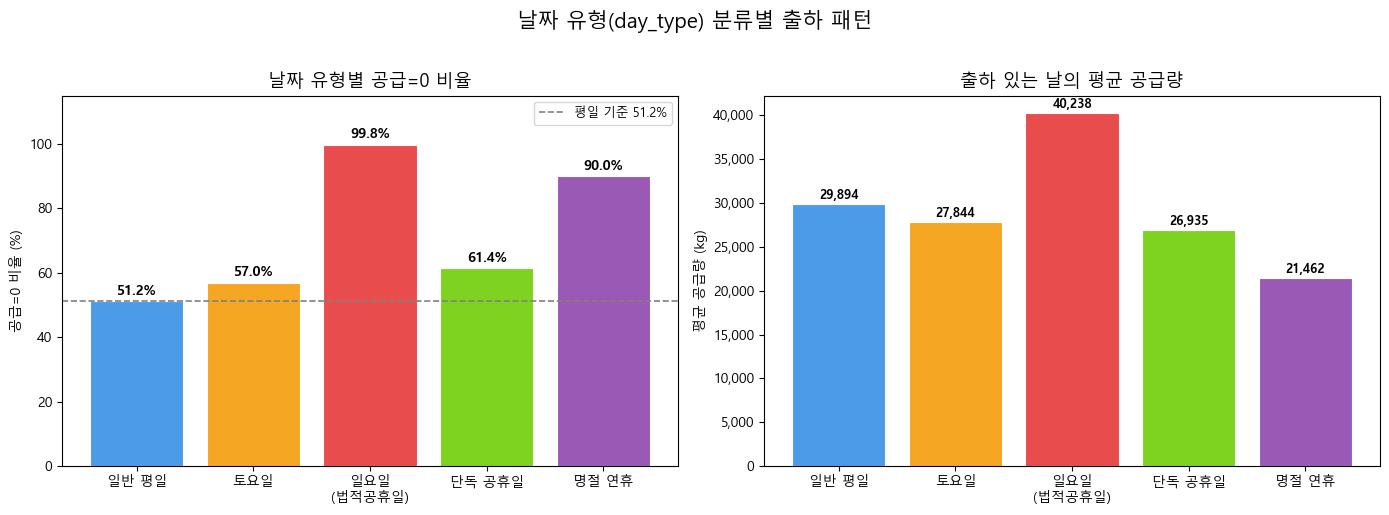

In [45]:
# ── 13-2. day_type별 공급=0 비율 & 평균 공급량 막대차트 ──────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

train["is_zero"] = train["supply(kg)"] == 0

stats = train.groupby("day_type").agg(
    zero_rate=("is_zero", "mean"),
    avg_supply=("supply(kg)", lambda x: x[x > 0].mean()),
).reset_index()
stats["label"] = stats["day_type"].map(DAY_LABELS)

COLORS = ["#4C9BE8", "#F5A623", "#E84C4C", "#7ED321", "#9B59B6"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars = ax.bar(stats["label"], stats["zero_rate"] * 100,
              color=COLORS, edgecolor="white", linewidth=0.8)
for bar, v in zip(bars, stats["zero_rate"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{v:.1%}", ha="center", va="bottom", fontsize=10, fontweight="bold")
baseline = stats.loc[stats["day_type"]==0, "zero_rate"].values[0] * 100
ax.axhline(baseline, color="gray", linestyle="--", linewidth=1.2,
           label=f"평일 기준 {baseline:.1f}%")
ax.set_title("날짜 유형별 공급=0 비율", fontsize=13)
ax.set_ylabel("공급=0 비율 (%)")
ax.set_ylim(0, 115)
ax.legend(fontsize=9)

ax2 = axes[1]
bars2 = ax2.bar(stats["label"], stats["avg_supply"],
                color=COLORS, edgecolor="white", linewidth=0.8)
for bar, v in zip(bars2, stats["avg_supply"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f"{v:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.set_title("출하 있는 날의 평균 공급량", fontsize=13)
ax2.set_ylabel("평균 공급량 (kg)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.suptitle("날짜 유형(day_type) 분류별 출하 패턴", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


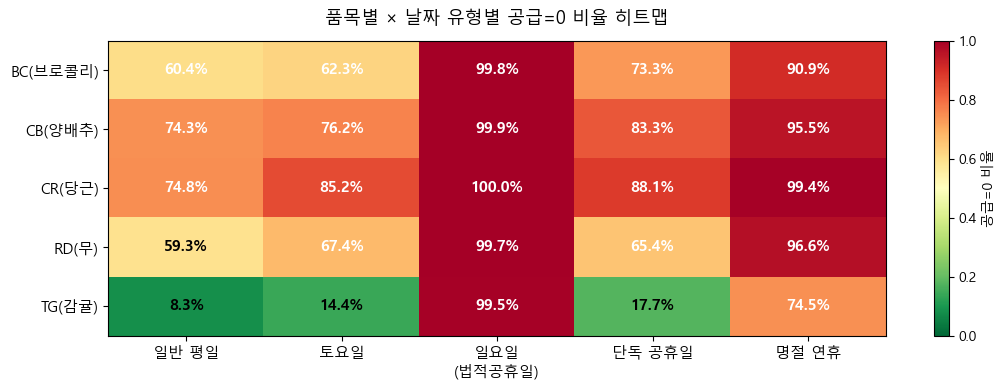

In [46]:
# ── 13-3. 품목 × day_type 공급=0 비율 히트맵 ──────────────────────
import numpy as np

ITEM_NAMES = {
    "TG": "TG(감귤)", "BC": "BC(브로콜리)", "CR": "CR(당근)",
    "CB": "CB(양배추)", "RD": "RD(무)"
}

pivot = train.groupby(["item", "day_type"])["is_zero"].mean().unstack()
pivot.index = [ITEM_NAMES.get(i, i) for i in pivot.index]
pivot.columns = [DAY_LABELS[c] for c in pivot.columns]

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(pivot.values, cmap="RdYlGn_r", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=11)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=11)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        color = "white" if val > 0.6 else "black"
        ax.text(j, i, f"{val:.1%}", ha="center", va="center",
                fontsize=11, color=color, fontweight="bold")
plt.colorbar(im, ax=ax, label="공급=0 비율")
ax.set_title("품목별 × 날짜 유형별 공급=0 비율 히트맵", fontsize=13, pad=12)
plt.tight_layout()
plt.show()


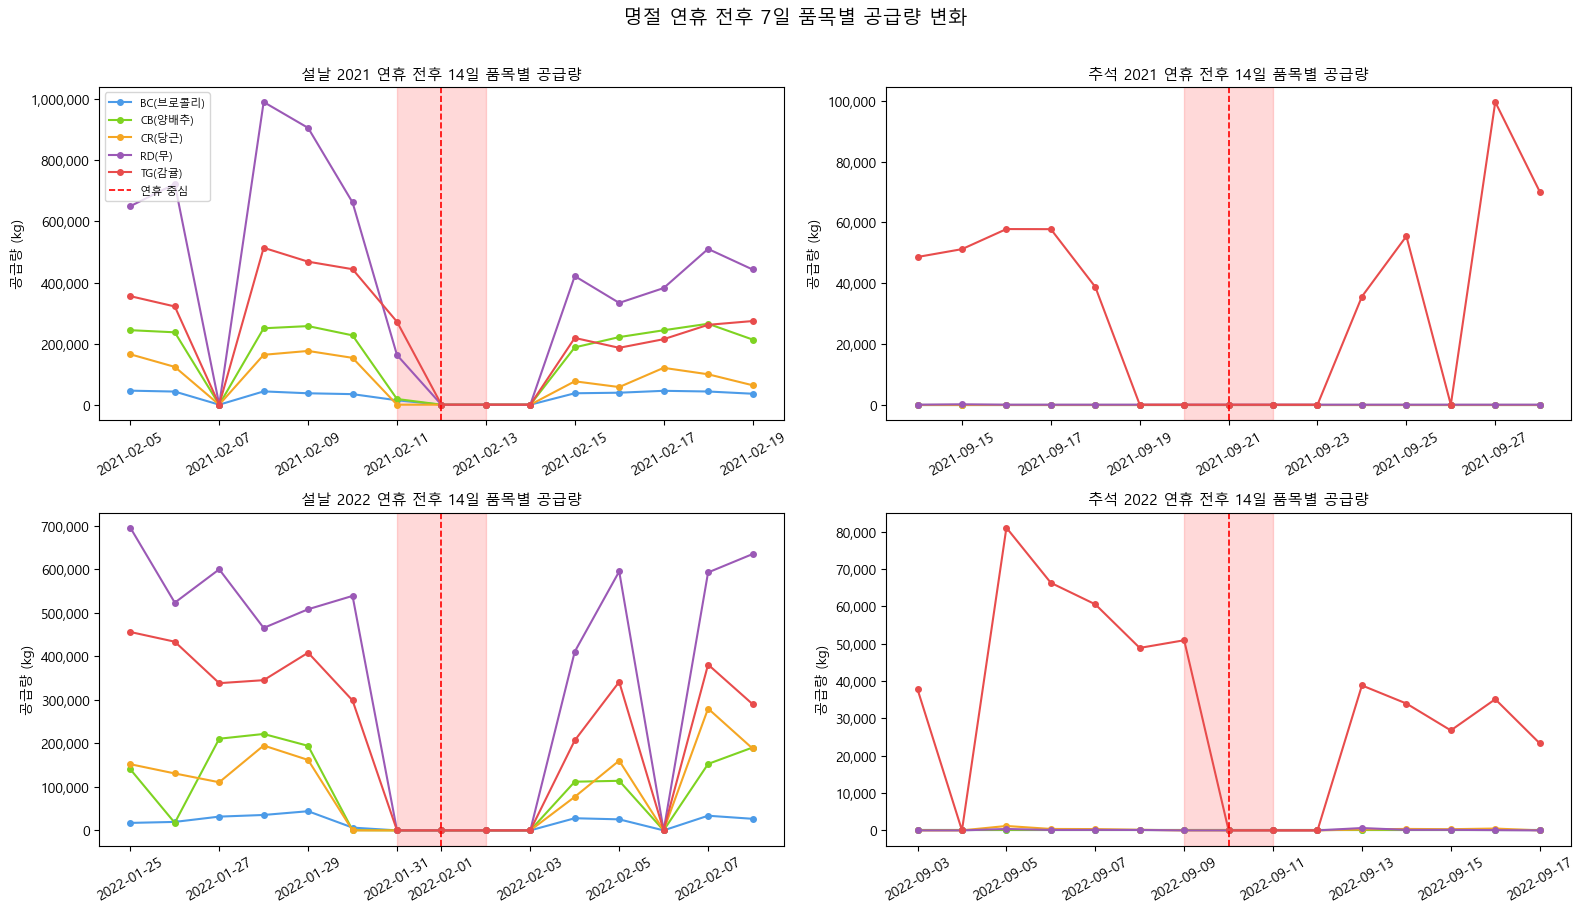

In [47]:
# ── 13-4. 명절 연휴 전후 7일 품목별 공급량 시계열 ──────────────────

MYEOL_CENTERS = {
    "설날 2021": "2021-02-12",
    "추석 2021": "2021-09-21",
    "설날 2022": "2022-02-01",
    "추석 2022": "2022-09-10",
}
ITEM_COLORS = {
    "TG": "#E84C4C", "BC": "#4C9BE8", "CR": "#F5A623",
    "CB": "#7ED321", "RD": "#9B59B6"
}

daily_sup = train.groupby([date_col, "item"])["supply(kg)"].sum().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for idx, (name, center) in enumerate(MYEOL_CENTERS.items()):
    cx = pd.to_datetime(center)
    s, e = cx - pd.Timedelta(days=7), cx + pd.Timedelta(days=7)
    ax = axes[idx]
    for item_code in sorted(train["item"].unique()):
        df_i = daily_sup[
            (daily_sup["item"] == item_code) &
            (daily_sup[date_col] >= s) &
            (daily_sup[date_col] <= e)
        ].sort_values(date_col)
        if len(df_i) == 0:
            continue
        ax.plot(df_i[date_col], df_i["supply(kg)"],
                marker="o", markersize=4, linewidth=1.5,
                label=ITEM_NAMES.get(item_code, item_code),
                color=ITEM_COLORS[item_code])
    ax.axvspan(cx - pd.Timedelta(days=1), cx + pd.Timedelta(days=1),
               alpha=0.15, color="red")
    ax.axvline(cx, color="red", linestyle="--", linewidth=1.2, label="연휴 중심")
    ax.set_title(f"{name} 연휴 전후 14일 품목별 공급량", fontsize=11)
    ax.set_ylabel("공급량 (kg)")
    ax.tick_params(axis="x", rotation=30)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    if idx == 0:
        ax.legend(fontsize=8, loc="upper left")

plt.suptitle("명절 연휴 전후 7일 품목별 공급량 변화", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


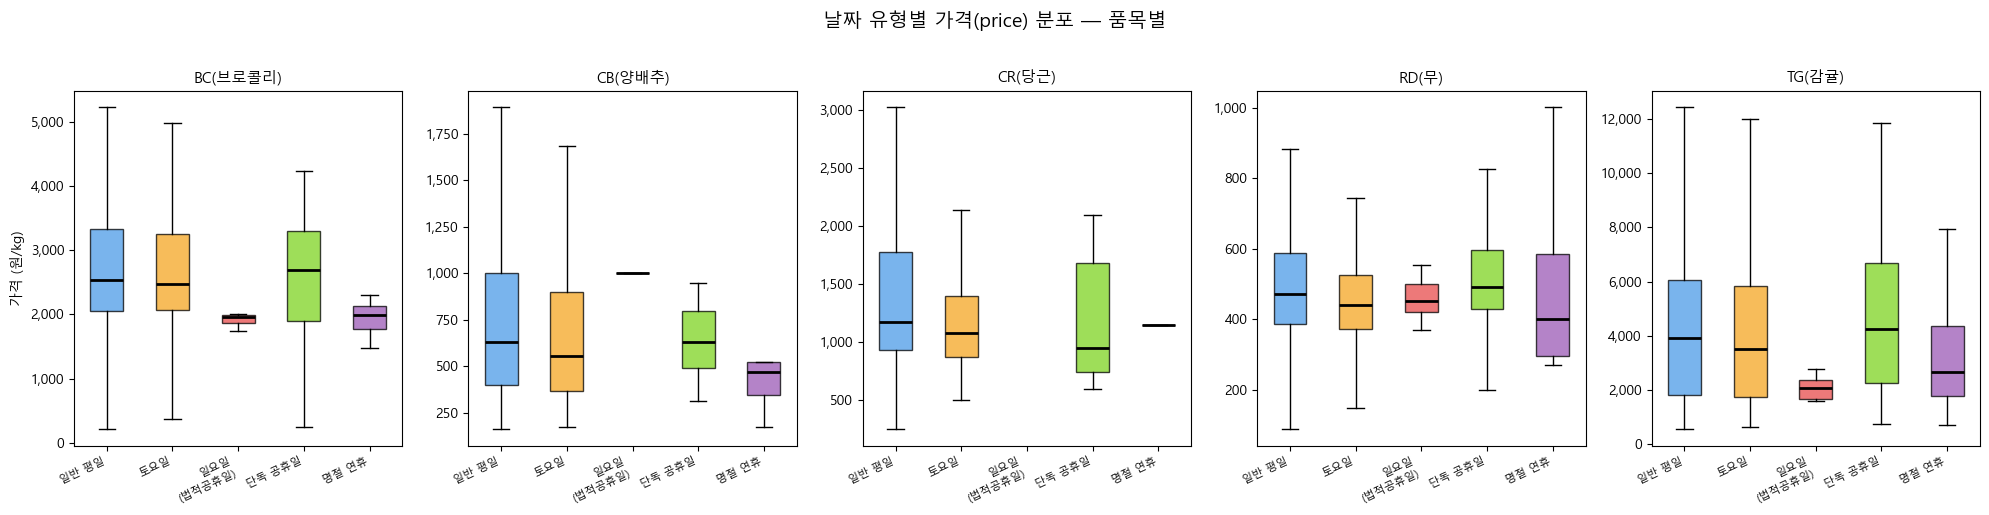

In [48]:
# ── 13-5. day_type별 가격 분포 박스플롯 (품목별) ──────────────────

train_price = train[train[target_col] > 0].copy()
train_price["day_label"] = train_price["day_type"].map(DAY_LABELS)
order = [DAY_LABELS[i] for i in range(5)]

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=False)
for ax, item_code in zip(axes, sorted(train["item"].unique())):
    df_item = train_price[train_price["item"] == item_code]
    data_by_type = [
        df_item[df_item["day_label"] == lbl][target_col].values
        for lbl in order
    ]
    bp = ax.boxplot(data_by_type, patch_artist=True, showfliers=False,
                    medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticklabels(order, fontsize=8, rotation=25, ha="right")
    ax.set_title(ITEM_NAMES.get(item_code, item_code), fontsize=11)
    ax.set_ylabel("가격 (원/kg)" if ax == axes[0] else "")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.suptitle("날짜 유형별 가격(price) 분포 — 품목별", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 공휴일 분류 분석 결과

| day_type | 유형 | 공급=0 비율 | 모델링 전략 |
|---|---|---|---|
| 0 | 일반 평일 | ~51% | 기준값 |
| 1 | 토요일 | ~56% | 평일과 유사, 별도 구분 |
| 2 | 일요일(법적공휴일) | **99.7%** | 사실상 휴장 → 0 또는 별도 처리 |
| 3 | 단독 공휴일 | ~74% | 품목별 출하 상이 → 교호작용 피처 |
| 4 | 명절 연휴 | **90%** | 마지막날 재개 패턴 주의 |

**핵심 인사이트**
- `토요일`과 `일요일`은 완전히 다른 패턴 → 기존 `is_weekend` 단일 피처는 정보 손실
- TG(감귤)는 공휴일 영향이 타 품목 대비 적음 → `item × day_type` 교호작용 피처 권장
- 명절 연휴 직전은 공급 급감, 직후는 공급 급증하는 반등 패턴 존재


In [49]:
print('=' * 60)
print('         EDA 인사이트 요약')
print('=' * 60)
print()
print('[데이터 구조]')
print(f'  - Train: {train.shape[0]:,}행 x {train.shape[1]}열')
print(f'  - Test : {test.shape[0]:,}행 x {test.shape[1]}열')
if date_col:
    print(f'  - 학습 기간: {train[date_col].min().date()} ~ {train[date_col].max().date()}')
if item_col:
    print(f'  - 예측 품목: {list(train[item_col].unique())}')
print()

print('[결측치]')
null_summary = train.isnull().sum()
if null_summary.sum() == 0:
    print('  - 결측치 없음')
else:
    for col, cnt in null_summary[null_summary > 0].items():
        print(f'  - {col}: {cnt}개 ({cnt/len(train)*100:.1f}%)')
print()

print('[타겟 변수]')
if target_col:
    print(f'  - 컬럼: {target_col}')
    print(f'  - 평균: {train[target_col].mean():.1f} 원/kg')
    print(f'  - 표준편차: {train[target_col].std():.1f} 원/kg')
    print(f'  - 왜도: {train[target_col].skew():.3f} (1 이상이면 로그 변환 권장)')
print()

print('[권장 모델링 방향]')
print('  1. 시계열 특성 피처 엔지니어링 (lag, rolling_mean, rolling_std)')
print('  2. 계절성 인코딩 (month, quarter, week sin/cos 변환)')
print('  3. 품목별 개별 모델 vs 통합 모델 비교')
print('  4. 추천 모델: LightGBM, XGBoost, Prophet, LSTM, N-BEATS')
print('  5. 타겟 로그 변환 여부 확인 후 결정')
print('=' * 60)

         EDA 인사이트 요약

[데이터 구조]
  - Train: 59,397행 x 15열
  - Test : 1,092행 x 5열
  - 학습 기간: 2019-01-01 ~ 2023-03-03
  - 예측 품목: ['TG', 'CR', 'CB', 'RD', 'BC']

[결측치]
  - 결측치 없음

[타겟 변수]
  - 컬럼: price(원/kg)
  - 평균: 1131.7 원/kg
  - 표준편차: 2029.9 원/kg
  - 왜도: 2.185 (1 이상이면 로그 변환 권장)

[권장 모델링 방향]
  1. 시계열 특성 피처 엔지니어링 (lag, rolling_mean, rolling_std)
  2. 계절성 인코딩 (month, quarter, week sin/cos 변환)
  3. 품목별 개별 모델 vs 통합 모델 비교
  4. 추천 모델: LightGBM, XGBoost, Prophet, LSTM, N-BEATS
  5. 타겟 로그 변환 여부 확인 후 결정



### 종합 인사이트 및 모델링 권고사항

**데이터 특성 요약**
- 59,397개 훈련 데이터, 다품목 시계열 구조
- 품목별 가격 패턴이 상이하며 계절성·추세·공급량이 가격에 유의미한 영향

**전처리 권고 (TensorFlow/Keras 딥러닝 기준)**

| 단계 | 방법 |
|------|------|
| **이상치 제거** | 품목×월 기준 Z-score \|Z\| > 3 이벤트성 이상치만 제거 → `train_filtered` 사용 |
| 날짜 순환 인코딩 | `month`, `dayofweek` → sin/cos 변환으로 순환 구조 표현 |
| 수치형 정규화 | `supply(kg)`, `year` 등 → RobustScaler (잔여 극단값에 강건) |
| 타겟 변환 | `np.log1p` 로그 변환 (왜도 감소, 예측 후 `np.expm1` 역변환) |
| 범주형 인코딩 | `item`, `corporation`, `location` → 정수 인덱스 + Embedding 레이어 |
| 결측치 처리 | 단기: 시계열 보간 / 구조적: 그룹 중앙값 대체 |
| 외부 피처 병합 | `international_trade.csv` → `import_weight`, `import_amount`, `trade_balance` (월별 left join) |
| 시퀀스 구성 | 과거 N일 윈도우를 슬라이딩하여 (samples, timesteps, features) 형태로 변환 |

**모델링 방향 (TensorFlow/Keras)**
- **LSTM / GRU**: 일별 시계열의 장·단기 의존성 학습에 적합, 기본 베이스라인
- **1D-CNN + LSTM**: CNN으로 지역 패턴을 추출하고 LSTM으로 시간 의존성 처리
- **Transformer (Multi-Head Attention)**: 장기 의존성 및 계절 패턴 포착에 강점
- **다중 입력 구조**: 수치형 시퀀스 + 범주형 Embedding을 병합하는 Keras Functional API 활용
- **품목별 개별 모델 vs 통합 모델**: 품목 간 패턴 차이가 크므로 `item` Embedding 포함 통합 모델 또는 품목별 개별 모델 비교 실험 권장
